In [2]:
%pip -q install -U metapub pdfplumber pandas lxml requests beautifulsoup4 tqdm
%pip -q install -U "transformers>=4.38" "accelerate>=0.26" "bitsandbytes>=0.43" "safetensors"

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


## Step 1:建立目录与配置

In [ ]:
import os, json, re, time
from pathlib import Path

CORPUS_DIR = Path("Annane_Sepsis_Corpus")
PAPERS_DIR = CORPUS_DIR / "papers"
OUT_DIR = CORPUS_DIR / "out"
VIZ_DIR = OUT_DIR / "viz"
VIZ_DIR.mkdir(parents=True, exist_ok=True)

PAPERS_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("CORPUS_DIR:", CORPUS_DIR.resolve())
print("PAPERS_DIR:", PAPERS_DIR.resolve())
print("OUT_DIR:", OUT_DIR.resolve())


CORPUS_DIR: C:\Users\27858\Downloads\Annane_Sepsis_Corpus
PAPERS_DIR: C:\Users\27858\Downloads\Annane_Sepsis_Corpus\papers
OUT_DIR: C:\Users\27858\Downloads\Annane_Sepsis_Corpus\out


## Step 2: Topic 检索 + 下载 PDF + sections.json

In [ ]:
from metapub import PubMedFetcher, FindIt
import requests
import pdfplumber
from tqdm.auto import tqdm

fetcher = PubMedFetcher()

TOPICS = {
    "sepsis_diagnosis_criteria": '(Annane D[Author] OR Djillali A[Author]) AND (sepsis OR "septic shock") AND (diagnosis OR criteria OR definition OR "Sepsis-3")',
    "sepsis_treatment_plan": '(Annane D[Author] OR Djillali A[Author]) AND (sepsis OR "septic shock") AND (treatment OR therapy OR management OR guideline OR hydrocortisone)',
    "steroid_sensitivity": '(Annane D[Author] OR Djillali A[Author]) AND (sepsis OR "septic shock") AND (corticosteroid OR hydrocortisone OR steroid) AND (response OR sensitivity OR resistance)',
}

TARGET_PER_TOPIC = 10

def pmid_search(query, retmax=200):
    # metapub 支持 fetcher.pmids_for_query
    pmids = fetcher.pmids_for_query(query, retmax=retmax)
    return [str(x) for x in pmids]

def is_pdf_bytes(b: bytes) -> bool:
    return b[:4] == b"%PDF"

def download_pdf_from_url(url, out_path: Path, timeout=60):
    r = requests.get(url, timeout=timeout, headers={"User-Agent":"Mozilla/5.0"})
    r.raise_for_status()
    data = r.content
    if not is_pdf_bytes(data):
        return False
    out_path.write_bytes(data)
    return True

def find_pdf_url(pmid: str):
    try:
        src = FindIt(pmid)
        if src.url:
            return src.url
        return None
    except Exception:
        return None

def pdf_to_text(pdf_path: Path, max_pages=10):
    text = []
    with pdfplumber.open(str(pdf_path)) as pdf:
        pages = pdf.pages[:max_pages]
        for p in pages:
            t = p.extract_text() or ""
            if t.strip():
                text.append(t)
    return "\n".join(text)

def sectionize_simple(full_text: str):
    # 非完美：先给你一个可稳定跑的最简分段（Abstract/Method/Conclusion）
    # 后续你可以升级为更强的 heading detector
    t = re.sub(r"\s+", " ", full_text).strip()
    sections = {"Abstract":"", "Method":"", "Conclusion":""}

    # 粗规则：按关键词切
    m = re.search(r"\b(METHODS?|PATIENTS?|DESIGN|SETTING)\b", t, flags=re.I)
    c = re.search(r"\b(CONCLUSION(S)?|RESULTS)\b", t, flags=re.I)

    if m:
        sections["Abstract"] = t[:m.start()].strip()
        if c and c.start() > m.start():
            sections["Method"] = t[m.start():c.start()].strip()
            sections["Conclusion"] = t[c.start():].strip()
        else:
            sections["Method"] = t[m.start():].strip()
    else:
        sections["Abstract"] = t[:4000]  # fallback

    return sections

def save_paper(pmid: str, topic: str, pdf_bytes_ok: bool, pdf_path: Path, sections: dict, meta: dict):
    paper_dir = PAPERS_DIR / f"PMID_{pmid}"
    paper_dir.mkdir(parents=True, exist_ok=True)

    if pdf_bytes_ok:
        # 已下载到 pdf_path（先写到 paper_dir）
        (paper_dir / "paper.pdf").write_bytes(pdf_path.read_bytes())

    sec_obj = {
        "pmid": pmid,
        "topic": topic,
        "pdf_path": str(paper_dir / "paper.pdf") if pdf_bytes_ok else None,
        "sectionizer": "simple_pdfplumber",
        "sections": sections,
        "meta": meta
    }
    (paper_dir / "sections.json").write_text(json.dumps(sec_obj, ensure_ascii=False, indent=2), encoding="utf-8")
    return paper_dir

def already_ready(paper_dir: Path):
    return (paper_dir/"paper.pdf").exists() and (paper_dir/"sections.json").exists()

tmp_pdf = OUT_DIR / "tmp_download.pdf"

for topic, query in TOPICS.items():
    print("\n" + "="*60)
    print("Topic:", topic)
    print("Query:", query)

    pmids = pmid_search(query, retmax=500)
    print("PMIDs:", len(pmids))

    saved = 0
    for pmid in tqdm(pmids[:500], desc=f"collect {topic}"):
        paper_dir = PAPERS_DIR / f"PMID_{pmid}"
        if already_ready(paper_dir):
            saved += 1
            if saved >= TARGET_PER_TOPIC:
                break
            continue

        url = find_pdf_url(pmid)
        if not url:
            continue

        ok_pdf = False
        try:
            ok_pdf = download_pdf_from_url(url, tmp_pdf)
        except Exception:
            ok_pdf = False

        if not ok_pdf:
            continue

        # 抽文本并分段
        ft = pdf_to_text(tmp_pdf, max_pages=12)
        secs = sectionize_simple(ft)
        meta = {"findit_url": url}

        save_paper(pmid, topic, True, tmp_pdf, secs, meta)
        saved += 1
        print(f"✅ {topic}: PMID {pmid} saved ({saved}/{TARGET_PER_TOPIC})")
        if saved >= TARGET_PER_TOPIC:
            break

    print(f"==> Done {topic}: {saved}/{TARGET_PER_TOPIC}")


2026-02-22 02:47:49 LAPTOP-4NMFDBK9 metapub.config[11424] WARNING NCBI_API_KEY was not set.
c:\Users\27858\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Topic: sepsis_diagnosis_criteria
Query: (Annane D[Author] OR Djillali A[Author]) AND (sepsis OR "septic shock") AND (diagnosis OR criteria OR definition OR "Sepsis-3")
PMIDs: 141


collect sepsis_diagnosis_criteria:  18%|█▊        | 26/141 [00:16<01:14,  1.53it/s]


==> Done sepsis_diagnosis_criteria: 10/10

Topic: sepsis_treatment_plan
Query: (Annane D[Author] OR Djillali A[Author]) AND (sepsis OR "septic shock") AND (treatment OR therapy OR management OR guideline OR hydrocortisone)
PMIDs: 228


collect sepsis_treatment_plan:  14%|█▍        | 32/228 [00:22<02:17,  1.42it/s]


==> Done sepsis_treatment_plan: 10/10

Topic: steroid_sensitivity
Query: (Annane D[Author] OR Djillali A[Author]) AND (sepsis OR "septic shock") AND (corticosteroid OR hydrocortisone OR steroid) AND (response OR sensitivity OR resistance)
PMIDs: 75


collect steroid_sensitivity:  31%|███       | 23/75 [00:16<00:38,  1.36it/s]

==> Done steroid_sensitivity: 10/10


## 读取一篇 READY paper

In [2]:
def get_first_ready_paper():
    for p in sorted(PAPERS_DIR.glob("PMID_*")):
        sec = p / "sections.json"
        pdf = p / "paper.pdf"
        if not (sec.exists() and pdf.exists()):
            continue
        obj = json.loads(sec.read_text(encoding="utf-8"))
        secs = obj.get("sections") or {}
        if any((v or "").strip() for v in secs.values()):
            return p, obj
    raise RuntimeError("No READY paper found")

def clean_pdf_text(t: str) -> str:
    t = t.replace("\x00", " ")
    t = re.sub(r"\s+", " ", t).strip()

    # 常见页眉/引用信息/作者单位行：直接删掉（保守）
    drop_patterns = [
        r"^critical care.*$",                 # 期刊页眉
        r"^intensive care med.*$",            # 期刊页眉
        r"^doi\s*:\s*\S+.*$",                 # DOI 行
        r"^vol\s*\d+.*$",                     # Vol 行
        r"^review.*clinical review.*$",       # Review 标题
        r"^guidelines.*$",                    # Guidelines 标题
        r"^copyright.*$",                     # copyright
        r"^open access.*$",                   # open access
    ]

    lines = [x.strip() for x in t.split("\n") if x.strip()]
    kept = []
    for ln in lines:
        low = ln.lower()
        if any(re.match(p, low) for p in drop_patterns):
            continue
        # 过短、像作者列表的也跳过
        if len(ln) < 25:
            continue
        kept.append(ln)

    return " ".join(kept)

def paper_text_from_sections(obj, max_chars=12000):
    """
    把 sections.json 的内容拼成：
    [ABSTRACT]
    ...
    [METHOD]
    ...
    这样 parse_section_blocks 才能识别。
    """
    secs = obj.get("sections") or {}
    parts = []

    # 尽量多给一些常见章节（不止 Method/Conclusion）
    order = [
        "Abstract", "Introduction", "Background",
        "Methods", "Method", "Patients", "Materials",
        "Results", "Discussion", "Conclusion",
        "Recommendation", "Guideline"
    ]

    for k in order:
        t = (secs.get(k) or "").strip()
        if t:
            parts.append(f"[{k.upper()}]\n{t}")  # ✅ header 单独一行 + 换行

    text = "\n\n".join(parts).strip()

    # 兜底：如果 sections 为空，就用 abstract 字段
    if not text:
        abs_ = (obj.get("abstract") or "").strip()
        if abs_:
            text = f"[ABSTRACT]\n{abs_}"

    return text[:max_chars]





## 加载 Gemma（4-bit，避免 kernel crash）

In [3]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_PATH = r"C:\Users\27858\hf_gemma_2b_it"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
    low_cpu_mem_usage=True,   # ✅ 更省内存
)

if not torch.cuda.is_available():
    model.to("cpu")

model.eval()
print("Loaded Gemma OK.")


def gemma_generate(prompt: str, max_new_tokens=160, temperature=0.2, max_input_tokens=1024):

    # gemma-it 用 chat template
    if hasattr(tokenizer, "apply_chat_template"):
        messages = [{"role": "user", "content": prompt}]
        enc = tokenizer.apply_chat_template(
            messages,
            add_generation_prompt=True,
            return_tensors="pt"
        )
        input_ids = enc.input_ids if hasattr(enc, "input_ids") else enc
    else:
        enc = tokenizer(prompt, return_tensors="pt")
        input_ids = enc["input_ids"]

    if input_ids.shape[-1] > max_input_tokens:
        input_ids = input_ids[:, -max_input_tokens:]

    input_ids = input_ids.to(model.device)

    with torch.no_grad():
        out = model.generate(
            input_ids=input_ids,
            max_new_tokens=max_new_tokens,
            do_sample=(temperature is not None and temperature > 0),
            temperature=float(temperature) if temperature else 1.0,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id,
        )

    gen_ids = out[0, input_ids.shape[-1]:]
    return tokenizer.decode(gen_ids, skip_special_tokens=True).strip()


print(gemma_generate("输出一个词:OK", max_new_tokens=20, temperature=0.0))


d:\Miniforge3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 164/164 [00:07<00:00, 22.29it/s, Materializing param=model.norm.weight]                              
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Loaded Gemma OK.
OK 是一个词，表示同意或接受。


核心修复：句子编号法（保证 quote 100% 来自文章）

In [ ]:
import re, json

# -----------------------------
# 1) 基础工具：句子切分 + 去噪
# -----------------------------
BAD_PATTERNS = [
    r"\bdoi\b", r"\bvol\b", r"\bissue\b", r"\bpages?\b", r"copyright",
    r"\bpmid\b", r"\bpmc\b", r"http[s]?://", r"@", r"conflict of interest",
    r"funding", r"affiliation", r"corresponding author"
]

"""def is_noise_sentence(s: str) -> bool:
    ss = (s or "").strip().lower()
    if len(ss) < 35:
        return True
    if any(re.search(p, ss) for p in BAD_PATTERNS):
        return True
    # 数字太多往往是引用/表格/作者信息
    if sum(ch.isdigit() for ch in ss) > 18:
        return True
    return False"""

NOISE_PATTERNS = [
    r"\bissn\b", r"\bdoi\b", r"\bvol\.?\b", r"\bissue\b",
    r"author manuscript", r"published in final edited form",
    r"springer", r"cochrane", r"wiley", r"elsevier",
    r"all rights reserved", r"copyright",
    r"\btable of contents\b", r"\bcontents\b",
    r"guidelines committee", r"surviving sepsis campaign",  # 这类常变成“标题/名单”
    r"\babstract\b.*\bonline\b",  # 类似“Online ISSN ... Abstract ...”
]

def is_noise_sentence(s: str) -> bool:
    if not s:
        return True
    t = s.strip()
    if len(t) < 40:
        return True
    low = t.lower()
    # 作者名单/机构名单：逗号密度很高且缺少谓词
    if low.count(",") >= 6 and not any(w in low for w in ["increase", "reduce", "associated", "defined", "recommend", "should", "mortality", "diagnos", "treat"]):
        return True
    # 断词/拼接碎片过多（跨栏拼接常见）
    if low.count("-") >= 3:
        return True
    for pat in NOISE_PATTERNS:
        if re.search(pat, low):
            return True
    return False

EVIDENCE_BAD_PATTERNS = [
    r"^keywords", r"\bissn\b", r"\bdoi\b", r"all rights reserved",
    r"zona\s+(glomerulosa|fasciculata|reticularis)",
    r"p450|cytochrome", r"\bcholesterol\b", r"\bketone\b",
    r"table\s*\d+|\bfigure\s*\d+",
    r"author manuscript|published in final edited form",
]

def is_bad_evidence(s: str) -> bool:
    """比 is_noise_sentence 更严格：专门干掉 evidence 里的“解剖/化学/出版信息/目录”等。"""
    if not s:
        return True
    low = s.strip().lower()
    for pat in EVIDENCE_BAD_PATTERNS:
        if re.search(pat, low):
            return True
    # 断裂残句：太短或像被截断
    if len(low) < 60:
        return True
    if low.endswith(("and", "or", "of", "to", "in", "with", "by")):
        return True
    return False

import re

def filter_evidence_quotes(evidence_quotes, max_keep=12, require_clinical=True):
    """
    更严格：尽量只保留能形成“诊断/治疗/预后/指南/试验结果”的句子
    """
    if not evidence_quotes:
        return []

    bad_re = re.compile(
        r"(?:\bissn\b|\bdoi\b|\bvol\b|\bissue\b|published online|author manuscript|all rights reserved|"
        r"copyright|correspondence:|affiliation|\btable\b|\bcontents\b|http[s]?://|\bpmid\b|\bpmc\b|"
        r"\bkeywords?\b)",  # ✅ 直接把 Keywords 行杀掉
        re.I
    )

    # ✅ “临床证据/结局/建议”强特征
    clinical_good = [
        "randomized", "trial", "controlled", "meta-analysis", "systematic review",
        "mortality", "survival", "risk", "hazard", "outcome", "endpoint",
        "recommend", "guideline", "should", "we propose", "decision tree",
        "treat", "therapy", "management", "dose", "low-dose", "high-dose",
        "effective", "benefit", "no benefit", "harm", "adverse",
        "diagnos", "criteria", "defined", "sensitivity", "resistance",
        "septic shock", "organ failure"
    ]

    # ✅ 纯生理机制/背景（在没有结局/建议词时）降级剔除
    mech_background = [
        "receptor", "axis", "cytokine", "metabolism", "synthesis",
        "physiologic", "regulated", "pathway", "hypothalamic", "pituitary",
        "glomerulosa", "fasciculata", "reticularis"  # 这种多是背景
    ]

    kept, seen = [], set()

    def norm(s): 
        return re.sub(r"\s+", " ", (s or "").strip().lower())

    for q in evidence_quotes:
        if not q:
            continue
        q = q.strip()

        # 太短/明显噪声
        if len(q) < 60:
            continue
        if bad_re.search(q):
            continue

        n = norm(q)
        if n in seen:
            continue
        seen.add(n)

        low = q.lower()

        # ✅ 需要临床证据特征
        has_clinical = any(k in low for k in clinical_good)
        has_mech = any(k in low for k in mech_background)

        if require_clinical and (not has_clinical):
            # 如果只有机制背景词且无临床词，直接扔
            if has_mech:
                continue
            # 其余非临床句也先扔（更干净）
            continue

        kept.append(q)
        if len(kept) >= max_keep:
            break

    return kept

ATTACK_CUES = [
    "no benefit", "no significant", "did not", "doubt", "failed to",
    "harm", "adverse", "worse", "increase mortality", "not recommended",
    "controversial", "casted serious doubt"
]
SUPPORT_CUES = [
    "reduced", "improved", "associated with lower", "benefit", "effective",
    "recommend", "should be used", "led to reconsider", "support the use",
    "decision tree", "replacement therapy"
]


# -----------------------------
# 1b) 临床相关过滤（Sepsis 诊断/症状/治疗/预后/并发症）
# -----------------------------
CLINICAL_KEYWORDS = [
    # sepsis & shock
    "sepsis", "septic", "septic shock", "shock",
    # diagnosis & criteria
    "diagnos", "definition", "criteria", "screen", "sofa", "qsofa", "sirs", "lactate",
    "blood culture", "infection", "suspected infection",
    # symptoms / signs
    "fever", "hypothermia", "hypotension", "tachycardia", "tachypnea",
    "respiratory", "organ dysfunction", "acute kidney", "oliguria", "mental status",
    # treatment
    "antibiotic", "antimicrobial", "fluid", "resuscitation", "vasopressor", "norepinephrine",
    "hydrocortisone", "corticosteroid", "steroid", "ventilation", "source control",
    # outcome / prognosis
    "mortality", "survival", "icu", "length of stay", "organ failure",
    # complications / prevention / sequelae
    "complication", "secondary infection", "long-term", "sequelae", "follow-up", "prevention"
]

NEGATION_HINTS = ["no ", "not ", "unlikely", "did not", "without", "lack of", "failed to", "cannot"]

def has_clinical_signal(s: str) -> bool:
    low = (s or "").lower()
    return any(k in low for k in CLINICAL_KEYWORDS)

def is_sepsis_context(s: str) -> bool:
    low = (s or "").lower()
    # 只要出现 sepsis/septic/shock/infection+organ dysfunction 等，就认为进入 sepsis 语境
    if "sepsis" in low or "septic" in low or "septic shock" in low:
        return True
    # 有些文章没直接写 sepsis，但写了感染+器官功能障碍/休克
    if ("infection" in low or "infectious" in low) and ("shock" in low or "organ dysfunction" in low or "icu" in low):
        return True
    return False

def is_clinical_sentence(s: str) -> bool:
    """
    句子是否值得作为 claim/evidence 的候选：
    - 既要有临床关键词（症状/诊断/治疗/预后）
    - 又要在 sepsis 语境里（避免抽到别的疾病泛讨论）
    """
    if not s:
        return False
    if not has_clinical_signal(s):
        return False
    if not is_sepsis_context(s):
        return False
    return True

def normalize_text_for_split(s: str) -> str:
    s = (s or "")
    # 断词： anti-inflam-\n matory -> anti-inflammatory
    s = re.sub(r"(\w)-\s*\n\s*(\w)", r"\1\2", s)
    # 去掉行内断词残留： anti-inflam- matory（有些抽取会变成空格而不是换行）
    s = re.sub(r"(\w)-\s+(\w)", r"\1\2", s)

    # 多余换行/空白归一
    s = s.replace("\x00", " ")
    s = re.sub(r"[ \t]+", " ", s)
    s = re.sub(r"\n{3,}", "\n\n", s)
    return s.strip()

def crop_true_abstract(abstract_text: str) -> str:
    """
    从 sections.json 的 Abstract 字段里截取“真正的摘要”：
    - 从第一次出现 'Abstract ' 或 'Abstract:' 后开始
    - 在 'Keywords' / 'Introduction' / 'Table' / 'Available online' 前截断
    """
    if not abstract_text:
        return ""
    t = abstract_text

    # 从 Abstract 起
    m = re.search(r"\bAbstract\b[:\s]", t, flags=re.IGNORECASE)
    if m:
        t = t[m.end():]

    # 在这些标记前截断（防止混进正文/表格）
    stop_markers = [r"\bKeywords?\b", r"\bIntroduction\b", r"\bTable\b", r"Available online", r"http[s]?://"]
    stops = []
    for sm in stop_markers:
        mm = re.search(sm, t, flags=re.IGNORECASE)
        if mm:
            stops.append(mm.start())
    if stops:
        t = t[:min(stops)]

    return t.strip()

def split_sentences_en(text: str):
    """英文为主的句子切分，尽量稳。"""
    t = normalize_text_for_split(text)
    if not t:
        return []

    # 先按换行拆块，再按句末符拆
    blocks = [b.strip() for b in re.split(r"[\r\n]+", t) if b.strip()]
    base = " ".join(blocks)

    sents = re.split(r"(?<=[\.\?\!])\s+|(?<=;)\s+", base)
    sents = [s.strip() for s in sents if s and len(s.strip()) > 20]

    # 过滤噪声
    sents = [s for s in sents if not is_noise_sentence(s)]
    return sents

# -----------------------------
# 2) 从你现有 text（包含 [SECTION]）中解析出 block
# -----------------------------
def parse_section_blocks(text: str):
    """
    兼容两种格式：
    1) [METHOD]   (单独一行)
       patients...
    2) [METHOD] patients...  (同一行)
    """
    if not text:
        return []

    blocks = []
    cur_sec = "Unknown"
    buf = []

    def flush():
        nonlocal buf, cur_sec
        if buf:
            blocks.append((cur_sec.title(), "\n".join(buf).strip()))
            buf = []

    for line in text.splitlines():
        line = line.rstrip()

        # ✅ 情况1/2：行首出现 [XXX]
        m = re.match(r"^\[(.+?)\]\s*(.*)$", line.strip())
        if m:
            flush()
            cur_sec = m.group(1).strip()
            rest = (m.group(2) or "").strip()
            if rest:
                buf.append(rest)  # ✅ 把同一行剩余正文也加入
        else:
            if line.strip():
                buf.append(line)

    flush()
    return blocks


# -----------------------------
# 3) 构造“编号句子列表”，按 section 权重优先
# -----------------------------
SEC_WEIGHT = {
    "Abstract": 5,
    "Conclusion": 5,
    "Results": 4,
    "Discussion": 3,
    "Recommendation": 5,
    "Guideline": 5,
    "Introduction": 2,
    "Background": 2,
    "Method": 1,
    "Methods": 1,
    "Patients": 1,
    "Materials": 1,
    "Unknown": 2,
}

TASK_KEYWORDS = [
    # sepsis core
    "sepsis", "septic shock", "infection", "organ dysfunction",
    # diagnosis / symptoms
    "diagnos", "defined", "criteria", "screen", "symptom", "hypotension", "fever", "lactate",
    # treatment / management
    "treat", "therapy", "corticosteroid", "hydrocortisone", "fludrocortisone", "antibiotic",
    "vasopressor", "norepinephrine", "fluid", "dose", "recommend", "guideline", "decision tree",
    # outcomes / prevention
    "mortality", "survival", "complication", "adverse", "risk", "prevent", "follow-up", "long-term"
]

def is_task_relevant_sentence(s: str) -> bool:
    low = (s or "").lower()
    return any(k in low for k in TASK_KEYWORDS)

def build_indexed_sentences_by_section(text: str, max_sents=80):
    blocks = parse_section_blocks(text)
    if not blocks:
        return [], ""
    
    for sec, sec_text in blocks:
        if sec.lower() == "abstract":
            sec_text = crop_true_abstract(sec_text)

    cand = []  # (weight, section, sent)
    for sec, sec_text in blocks:
        w = SEC_WEIGHT.get(sec, 2)
        for s in split_sentences_en(sec_text):
            if is_noise_sentence(s):
                continue
            if not is_task_relevant_sentence(s):
                continue
            cand.append((w, sec, s))

    # 如果过滤太狠 -> 降级：不做噪声过滤
    if len(cand) < 8:
        cand = []
        for sec, sec_text in blocks:
            w = SEC_WEIGHT.get(sec, 2)
            for s in split_sentences_en(sec_text):
                if len((s or "").strip()) < 25:
                    continue
                cand.append((w, sec, s))

    cand.sort(key=lambda x: x[0], reverse=True)
    cand = cand[:max_sents]

    # 句子列表（保留 section 信息）
    sents = [{"sec": sec, "sent": sent} for _, sec, sent in cand]

    indexed_lines = []
    for i, item in enumerate(sents, start=1):
        indexed_lines.append(f"{i}. [{item['sec'].upper()}] {item['sent']}")
    indexed = "\n".join(indexed_lines)

    return sents, indexed

# -----------------------------
# 4) 让 Gemma 只输出固定文本格式（避免 JSON 崩）
# -----------------------------
def build_quote_pick_prompt(paper_id, topic, indexed_sents_text):
    return f"""
你是医学论证结构抽取助手。

请从下面“编号句子”里挑选：
- CLAIM：1句话，必须是观点/结论/诊断依据/治疗建议相关，不要选作者/期刊/DOI/引用列表。
- E1/E2/E3：3句话，分别作为支持或补充 CLAIM 的证据（尽量来自不同 section）。

严格按照下面格式输出（不要输出其它内容，不要JSON，不要解释）：
CLAIM: <编号>
E1: <编号>
E2: <编号>
E3: <编号>

paper_id={paper_id}
topic={topic}

编号句子：
{indexed_sents_text}
""".strip()

def parse_pick_output(raw: str, n_sents: int):
    """
    解析：
      CLAIM: 12
      E1: 5
      E2: 8
      E3: 3
    """
    if not raw:
        raise ValueError("Empty model output")
    def grab(tag):
        m = re.search(rf"{tag}\s*:\s*(\d+)", raw, flags=re.IGNORECASE)
        return int(m.group(1)) if m else None

    claim_id = grab("CLAIM")
    e1 = grab("E1")
    e2 = grab("E2")
    e3 = grab("E3")

    # 兜底
    claim_id = claim_id or 1
    ev_ids = [e for e in [e1, e2, e3] if e is not None]
    if len(ev_ids) < 3:
        # 补齐
        for i in range(2, 2 + (3 - len(ev_ids))):
            ev_ids.append(i)

    # 边界修正
    claim_id = max(1, min(claim_id, n_sents))
    ev_ids = [max(1, min(i, n_sents)) for i in ev_ids]
    # 去重并保证3个
    ev_ids = list(dict.fromkeys(ev_ids))
    i = 1
    while len(ev_ids) < 3 and i <= n_sents:
        if i != claim_id and i not in ev_ids:
            ev_ids.append(i)
        i += 1
    while len(ev_ids) < 3:
        ev_ids.append(ev_ids[-1])

    # 避免 evidence 跟 claim 一样
    ev_ids = [i for i in ev_ids if i != claim_id]
    while len(ev_ids) < 3:
        ev_ids.append(1 if claim_id != 1 else 2)

    return claim_id, ev_ids[:3]


import json

def _extract_first_json(text: str):
    if not text:
        return None
    t = text.strip()
    start = t.find("{")
    if start < 0:
        return None
    depth = 0
    for i in range(start, len(t)):
        if t[i] == "{":
            depth += 1
        elif t[i] == "}":
            depth -= 1
            if depth == 0:
                blob = t[start:i+1]
                try:
                    return json.loads(blob)
                except Exception:
                    return None
    return None

import re

def _dose_tag(text: str) -> str:
    """粗粒度识别剂量语义：high / low / any / unknown"""
    t = (text or "").lower()

    high = bool(re.search(r"\bhigh[-\s]?dose\b|\bsupra[-\s]?physiologic(al)?\b", t))
    low  = bool(re.search(r"\blow[-\s]?dose\b|\bphysiologic(al)?\b|\breplacement\b", t))
    anyc = bool(re.search(r"\bcorticosteroid|glucocorticoid|hydrocortisone|cortisol\b", t))

    if high and not low: return "high"
    if low and not high: return "low"
    if high and low: return "mixed"   # 同时提到 high/low，可能是对比句
    if anyc: return "any"
    return "unknown"

def infer_polarity(claim: str, evidence: str) -> str:
    """
    返回: support / attack / irrelevant
    逻辑：
    1) 先检查 claim 与 evidence 是否在同一剂量/同一干预维度上（不一致就 irrelevant）
    2) 再用更明确的“结局/推荐/否定”线索判 support/attack
    """
    c = (claim or "")
    e = (evidence or "")
    cl = c.lower()
    el = e.lower()

    c_dose = _dose_tag(cl)
    e_dose = _dose_tag(el)

    # --- 剂量一致性硬规则 ---
    # claim讲 high-dose，evidence讲 low-dose（且不对比） => irrelevant
    if c_dose == "high" and e_dose == "low":
        # 如果 evidence 明确在对比 high vs low，才不是 irrelevant
        if not re.search(r"\b(high|low)[-\s]?dose\b.*\b(high|low)[-\s]?dose\b", el):
            return "irrelevant"

    # claim讲 low-dose，evidence讲 high-dose（且不对比） => irrelevant
    if c_dose == "low" and e_dose == "high":
        if not re.search(r"\b(high|low)[-\s]?dose\b.*\b(high|low)[-\s]?dose\b", el):
            return "irrelevant"

    # --- 明确 attack 线索 ---
    ATTACK = [
        "no benefit", "no significant", "did not", "failed to",
        "casted serious doubt", "serious doubt", "abandoned",
        "ineffective", "harm", "worse", "increased mortality",
        "not recommended", "should not", "contraindicated"
    ]
    if any(x in el for x in ATTACK):
        return "attack"

    # --- 明确 support 线索 ---
    SUPPORT = [
        "beneficial", "effective", "recommend", "should be used",
        "reduce mortality", "improve", "associated with lower",
        "led to a reconsideration", "decision tree",
        "replacement therapy", "cortisol replacement"
    ]
    if any(x in el for x in SUPPORT):
        return "support"

    # 如果完全看不出关系，就 irrelevant
    return "irrelevant"

# -----------------------------
# 5) 主函数：pick_quotes_by_ids
# -----------------------------
import re

FOCUS_KW = [
    # diagnosis / criteria
    "diagnos", "criteria", "definition", "sepsis-3", "septic shock", "qsofa", "sofa",
    "organ dysfunction", "lactate", "infection", "hypotension",
    # treatment / recommendation
    "treat", "therapy", "management", "recommend", "should", "we suggest",
    "hydrocortisone", "fludrocortisone", "antibiotic", "vasopressor", "fluid", "steroid",
    # outcomes / adverse / long-term
    "mortality", "survival", "adverse", "side effect", "complication", "long-term", "sequelae",
    "follow-up", "prevention", "risk"
]

NEGATION_KW = ["no", "not", "did not", "without", "lack of", "failed to", "doubt", "controversial"]

NOISE_KW = [
    "issn", "doi", "vol", "issue", "pages", "copyright", "all rights reserved",
    "author manuscript", "published in final edited form",
    "springer", "elsevier", "wiley", "cochrane", "table of contents",
    "guidelines committee", "corresponding author", "affiliation"
]

def clean_prefix(s: str) -> str:
    if not s:
        return ""
    s = s.strip()
    # 去掉 [ABSTRACT] 这类 tag
    s = re.sub(r"^\[[A-Z_]+\]\s*", "", s).strip()
    # 去掉明显出版信息前缀（ISSN/Online ISSN/Abstract）
    s = re.sub(r"^(online\s+)?issn.*?\)\s*", "", s, flags=re.I).strip()
    s = re.sub(r"^abstract\s*", "", s, flags=re.I).strip()
    return s

def is_noise(s: str) -> bool:
    if not s:
        return True
    low = s.lower().strip()
    if len(low) < 35:
        return True
    if any(k in low for k in NOISE_KW):
        return True
    # 作者名单：逗号特别多且几乎没有动词
    if low.count(",") >= 6 and not any(v in low for v in ["is", "are", "was", "were", "increase", "reduce", "associated", "recommend", "suggest", "define", "treat"]):
        return True
    return False

def score_sentence(s: str) -> float:
    low = s.lower()
    score = 0.0
    for kw in FOCUS_KW:
        if kw in low:
            score += 2.0
    # 偏好“有结论/建议”的句子
    if any(x in low for x in ["we recommend", "should", "suggest", "defined as", "is defined", "was associated", "reduced mortality"]):
        score += 2.5
    # 长度适中加分
    if 60 <= len(s) <= 240:
        score += 1.0
    # 太长像拼接/表格减分
    if len(s) > 320:
        score -= 2.0
    return score


import re

FOCUS_KW = [
    "sepsis", "septic shock", "infection", "organ dysfunction", "mortality", "survival",
    "diagnos", "criteria", "definition", "sofa", "qsofa", "lactate", "hypotension",
    "treat", "therapy", "management", "recommend", "should", "we suggest",
    "hydrocortisone", "fludrocortisone", "steroid", "vasopressor", "fluid", "antibiotic",
    "adverse", "side effect", "complication", "long-term", "sequela", "follow-up", "prevention", "risk"
]

NOISE_KW = [
    "issn", "doi", "vol", "issue", "pages", "copyright", "all rights reserved",
    "author manuscript", "published in final edited form",
    "springer", "elsevier", "wiley", "cochrane", "table of contents",
    "guidelines committee", "corresponding author", "affiliation"
]

NEGATION_KW = ["no", "not", "did not", "without", "lack of", "failed to", "doubt", "controversial"]

def normalize_text(s: str) -> str:
    s = (s or "")
    # 1) 处理断词： "anti-inflam- \n matory" -> "anti-inflammatory"
    s = re.sub(r"(\w)-\s*\n\s*(\w)", r"\1\2", s)
    # 2) 换行变空格
    s = re.sub(r"\s*\n\s*", " ", s)
    # 3) 多空格收敛
    s = re.sub(r"\s{2,}", " ", s)
    return s.strip()

def clean_prefix(s: str) -> str:
    s = normalize_text_for_split((s or "").strip())
    # 去 section tag
    s = re.sub(r"^\[[A-Z_]+\]\s*", "", s).strip()
    # 常见出版噪声
    s = re.sub(r"^(online\s+)?issn.*?\)\s*", "", s, flags=re.I).strip()
    s = re.sub(r"^abstract\s*", "", s, flags=re.I).strip()
    return s

def is_noise(s: str) -> bool:
    low = (s or "").lower().strip()
    if len(low) < 35:
        return True
    if any(k in low for k in NOISE_KW):
        return True
    # 作者名单：逗号超多且缺少动词
    if low.count(",") >= 6 and not any(v in low for v in ["is","are","was","were","increase","reduce","associated","recommend","suggest","define","treat"]):
        return True
    return False

def score_sentence(s: str) -> float:
    low = s.lower()
    sc = 0.0
    for kw in FOCUS_KW:
        if kw in low:
            sc += 2.0
    # 更偏好“建议/定义/结论”
    if any(x in low for x in ["we recommend", "should", "we suggest", "is defined", "defined as", "was associated", "reduced mortality", "increased mortality"]):
        sc += 2.5
    # 长度适中
    if 60 <= len(s) <= 260:
        sc += 1.0
    if len(s) > 360:
        sc -= 2.0
    return sc


CLAIM_STRONG_KW = [
    "we recommend", "should", "we suggest", "is defined", "defined as",
    "we conclude", "conclude", "our results", "this study shows",
    "was associated", "reduced mortality", "increased mortality",
    "improves", "effective", "ineffective", "no benefit"
]

def is_good_claim(s: str) -> bool:
    low = s.lower()
    return any(k in low for k in CLAIM_STRONG_KW)

CLAIM_CUES = [
    "we propose", "we recommend", "should", "guideline", "decision tree",
    "is defined as", "controversial", "the aim", "conclusions", "conclude",
    "associated with", "support the use", "evidence suggests"
]

def score_claim(s: str) -> float:
    low = (s or "").lower()
    score = 0.0
    if "sepsis" in low or "septic shock" in low:
        score += 2.0
    for c in CLAIM_CUES:
        if c in low:
            score += 2.0
    # 疑似 attack 句降低它做 claim 的可能性
    if any(x in low for x in ["no benefit", "did not", "failed", "casted serious doubt"]):
        score -= 1.5
    # 过长且有很多破折号的跨栏句降低
    if low.count("-") >= 3:
        score -= 0.5
    return score

import re

import re

import re

def pick_quotes_nested(
    paper_id,
    topic,
    text,
    parent_quote=None,  # 🆕 新增：如果不为 None，则为子证据抽取
    max_sents=200,
    max_evidence=12,
    depth=2,  # 🆕 深度限制（1=只有claim+evidence，2=嵌套1层）
    current_depth=1,
    use_gemma=True,
    min_sa=2,
    min_pool_abstract=6,
):
    """
    递归版 pick_quotes：支持多层嵌套
    
    
    - parent_quote: 如果抽取子证据，传入父证据的 quote
    - depth: 最大递归深度
    - current_depth: 当前递归深度
    """
    
    def _norm(s: str) -> str:
        return re.sub(r"\s+", " ", (s or "").strip().lower())

    def _tokenize(s: str):
        s = _norm(s)
        toks = re.findall(r"[a-z]{3,}", s)
        stop = {
            "this","that","with","from","were","have","has","had","been","into","than",
            "also","such","their","which","these","those","between","within",
            "study","review","present","paper","article","authors","published",
            "abstract","introduction","results","discussion","conclusion"
        }
        return [t for t in toks if t not in stop]

    def _dose_tag(s: str) -> str:
        t = _norm(s)
        high = bool(re.search(r"\bhigh[-\s]?dose\b|\bsupra[-\s]?physiologic(al)?\b", t))
        low  = bool(re.search(r"\blow[-\s]?dose\b|\bphysiologic(al)?\b|\breplacement\b", t))
        anyc = bool(re.search(r"\bcorticosteroid|glucocorticoid|hydrocortisone|cortisol\b", t))
        if high and not low: return "high"
        if low and not high: return "low"
        if high and low: return "mixed"
        if anyc: return "any"
        return "unknown"

    def _dose_compatible(claim_txt: str, ev_txt: str) -> bool:
        c = _norm(claim_txt)
        e = _norm(ev_txt)
        cd = _dose_tag(c)
        ed = _dose_tag(e)
        if cd == "high" and ed == "low":
            if not re.search(r"\b(high|low)[-\s]?dose\b.*\b(high|low)[-\s]?dose\b", e):
                return False
        if cd == "low" and ed == "high":
            if not re.search(r"\b(high|low)[-\s]?dose\b.*\b(high|low)[-\s]?dose\b", e):
                return False
        return True

    def _clinical_score(sent: str) -> float:
        t = _norm(sent)
        score = 0.0
        if "sepsis" in t or "septic shock" in t:
            score += 2.0
        if any(k in t for k in ["diagnos", "criteria", "defined", "definition", "symptom", "sign", "risk", "screen"]):
            score += 2.0
        if any(k in t for k in ["treat", "therapy", "management", "recommend", "should", "dose", "duration", "administ", "replacement"]):
            score += 2.0
        if any(k in t for k in ["mortality", "survival", "outcome", "organ failure", "shock", "icu", "length of stay"]):
            score += 2.0
        if any(k in t for k in ["trial", "random", "controlled", "meta-analysis", "systematic review", "cohort", "odds ratio", "risk ratio", "hazard", "associated"]):
            score += 1.5
        if any(k in t for k in ["this review summarizes", "the present review", "mechanism", "receptor", "cytokine", "metabolism"]) and not any(
            k in t for k in ["mortality", "recommend", "treat", "diagnos", "trial", "associated"]
        ):
            score -= 1.0
        if len(t) < 60:
            score -= 1.0
        return score

    def _claim_score(sent: str) -> float:
        t = _norm(sent)
        score = _clinical_score(sent)
        if any(k in t for k in ["we propose", "we recommend", "should", "recommend", "decision tree", "we suggest"]):
            score += 1.5
        if any(k in t for k in ["controvers", "doubt", "uncertain", "no benefit", "ineffective", "harm", "abandoned", "not recommended"]):
            score += 1.0
        if any(k in t for k in ["the adrenal", "axis", "pathway", "receptor"]) and not any(k in t for k in ["should", "recommend", "mortality", "trial", "diagnos", "treat"]):
            score -= 0.5
        return score

    def _overlap_score(claim_txt: str, ev_txt: str) -> float:
        c_toks = set(_tokenize(claim_txt))
        e_toks = set(_tokenize(ev_txt))
        if not c_toks or not e_toks:
            return 0.0
        jacc = len(c_toks & e_toks) / max(1, len(c_toks | e_toks))
        bonus = 0.0
        key_phrases = ["mortality", "survival", "septic shock", "corticosteroid", "glucocorticoid", "hydrocortisone", "adrenal insufficiency"]
        ct = _norm(claim_txt)
        et = _norm(ev_txt)
        for kp in key_phrases:
            if kp in ct and kp in et:
                bonus += 0.2
        return jacc + bonus

    # ========== 主逻辑 ==========
    
    # 1. 如果是根节点（抽取 Claim），直接内联原逻辑
    if parent_quote is None:
    
        sents, _ = build_indexed_sentences_by_section(text, max_sents=max_sents)
        if not sents:
            fallback = (text or "").strip()[:500] or "No usable text extracted from paper sections."
            return {
                "paper_id": paper_id,
                "topic": topic,
                "claim_quote": fallback,
                "evidence_quotes": [],
                "polarities": [],
                "debug": {"reason": "no_sents"}
            }

        # section 分桶
        abs_pool = [x for x in sents if (x.get("sec") or "").lower() == "abstract"]
        concl_pool = [x for x in sents if (x.get("sec") or "").lower() in ("conclusion", "recommendation", "guideline")]
        results_pool = [x for x in sents if (x.get("sec") or "").lower() == "results"]
        discuss_pool = [x for x in sents if (x.get("sec") or "").lower() in ("discussion",)]
        intro_pool = [x for x in sents if (x.get("sec") or "").lower() in ("introduction", "background")]

        pool_primary = abs_pool if len(abs_pool) >= min_pool_abstract else sents

        # 选 claim
        claim_item = max(pool_primary, key=lambda x: _claim_score(x.get("sent", "")))
        claim_quote = f"[{claim_item['sec'].upper()}] {claim_item['sent']}"

        # 生成候选 evidence
        pools_order = [
            ("abstract", abs_pool),
            ("conclusion", concl_pool),
            ("results", results_pool),
            ("discussion", discuss_pool),
            ("intro", intro_pool),
            ("all", sents),
        ]

        def _to_quote(it):
            return f"[{it['sec'].upper()}] {it['sent']}"

        cand_evs = []
        used_layers = []
        for name, pool in pools_order:
            if not pool:
                continue
            used_layers.append(name)

            for it in pool:
                q = _to_quote(it)
                cand_evs.append(q)

            cand_evs = [q for q in cand_evs if q.strip() and q.strip() != claim_quote.strip()]
            cand_evs = filter_evidence_quotes(cand_evs, max_keep=max_evidence * 6, require_clinical=True)

            if len(cand_evs) >= max(12, max_evidence * 2):
                break

        if len(cand_evs) < 4:
            cand_evs = []
            for name, pool in pools_order:
                if not pool:
                    continue
                for it in pool:
                    q = _to_quote(it)
                    cand_evs.append(q)
            cand_evs = [q for q in cand_evs if q.strip() and q.strip() != claim_quote.strip()]
            cand_evs = filter_evidence_quotes(cand_evs, max_keep=max_evidence * 8, require_clinical=False)

        # evidence "对齐排序"
        scored = []
        for q in cand_evs:
            q_txt = re.sub(r"^\[[A-Z]+\]\s*", "", q).strip()
            c_txt = re.sub(r"^\[[A-Z]+\]\s*", "", claim_quote).strip()
            s = 1.5 * _overlap_score(c_txt, q_txt) + 0.5 * _clinical_score(q_txt)
            scored.append((s, q))
        scored.sort(key=lambda x: x[0], reverse=True)
        cand_evs = [q for _, q in scored][: max_evidence * 5]

        # polarity 判断
        polarities = []
        for q in cand_evs:
            p = infer_polarity(claim_quote, q)
            if p in ("support", "attack") and not _dose_compatible(claim_quote, q):
                p = "irrelevant"
            polarities.append(p)

        paired = list(zip(cand_evs, polarities))
        sa = [(q, p) for (q, p) in paired if p in ("support", "attack")]

        if len(sa) < min_sa:
            extra = []
            for name, pool in pools_order:
                if not pool:
                    continue
                for it in pool:
                    extra.append(_to_quote(it))
            extra = [q for q in extra if q.strip() and q.strip() != claim_quote.strip()]
            extra = filter_evidence_quotes(extra, max_keep=max_evidence * 10, require_clinical=False)

            seen = set(_norm(q) for q in cand_evs)
            extra = [q for q in extra if _norm(q) not in seen]
            extra = extra[: max_evidence * 6]

            extra_scored = []
            c_txt = re.sub(r"^\[[A-Z]+\]\s*", "", claim_quote).strip()
            for q in extra:
                q_txt = re.sub(r"^\[[A-Z]+\]\s*", "", q).strip()
                s = 1.5 * _overlap_score(c_txt, q_txt) + 0.5 * _clinical_score(q_txt)
                extra_scored.append((s, q))
            extra_scored.sort(key=lambda x: x[0], reverse=True)
            extra = [q for _, q in extra_scored][: max_evidence * 3]

            extra_pols = []
            for q in extra:
                p = infer_polarity(claim_quote, q)
                if p in ("support", "attack") and not _dose_compatible(claim_quote, q):
                    p = "irrelevant"
                extra_pols.append(p)

            extra_sa = [(q, p) for (q, p) in zip(extra, extra_pols) if p in ("support", "attack")]
            sa.extend(extra_sa)

        if not sa:
            kept = cand_evs[:min(len(cand_evs), max(3, max_evidence//2))]
            return {
                "paper_id": paper_id,
                "topic": topic,
                "claim_quote": claim_quote,
                "evidence_quotes": kept,
                "polarities": ["irrelevant"] * len(kept),
                "debug": {
                    "n_candidates": len(sents),
                    "n_abs": len(abs_pool),
                    "n_cand_evidence": len(cand_evs),
                    "n_support_attack": 0,
                    "used_layers": used_layers,
                    "note": "no support/attack detected; kept a few as irrelevant fallback"
                }
            }

        attacks = [x for x in sa if x[1] == "attack"]
        supports = [x for x in sa if x[1] == "support"]

        final = []
        if attacks:
            final.append(attacks[0])
        if supports:
            final.append(supports[0])

        c_txt = re.sub(r"^\[[A-Z]+\]\s*", "", claim_quote).strip()
        rest = []
        for q, p in (attacks[1:] + supports[1:]):
            q_txt = re.sub(r"^\[[A-Z]+\]\s*", "", q).strip()
            s = 1.5 * _overlap_score(c_txt, q_txt) + 0.5 * _clinical_score(q_txt)
            rest.append((s, q, p))
        rest.sort(key=lambda x: x[0], reverse=True)

        for _, q, p in rest:
            if len(final) >= max_evidence:
                break
            final.append((q, p))

        seen = set()
        ev_out, pol_out = [], []
        for q, p in final:
            k = _norm(q)
            if k in seen:
                continue
            seen.add(k)
            ev_out.append(q)
            pol_out.append(p)
            if len(ev_out) >= max_evidence:
                break

        root_result = {
            "paper_id": paper_id,
            "topic": topic,
            "claim_quote": claim_quote,
            "evidence_quotes": ev_out,
            "polarities": pol_out,
            "debug": {
                "n_candidates": len(sents),
                "n_abs": len(abs_pool),
                "n_cand_evidence": len(cand_evs),
                "n_support_attack": len(sa),
                "used_layers": used_layers,
                "use_gemma": bool(use_gemma),
            }
        }
        
        # 🆕 如果 depth > 1，为每条 evidence 递归抽取子证据
        if depth > 1 and current_depth < depth:
            nested_evidence = []
            for ev_quote in root_result["evidence_quotes"][:6]:  # 🔧 限制只为前6条加子证据（避免爆炸）
                try:
                    sub_result = pick_quotes_nested(
                        paper_id, topic, text,
                        parent_quote=ev_quote,  # 🆕 传入父证据
                        max_sents=max_sents,
                        max_evidence=4,  # 🔧 子证据只抽4条
                        depth=depth,
                        current_depth=current_depth + 1,
                        use_gemma=False,  # 🔧 子证据用规则（避免模型调用过多）
                        min_sa=1
                    )
                    nested_evidence.append({
                        "parent_quote": ev_quote,
                        "children": sub_result["evidence_quotes"],
                        "polarities": sub_result["polarities"]
                    })
                except Exception as e:
                    print(f"⚠️ 子证据抽取失败: {repr(e)}")
                    nested_evidence.append({"parent_quote": ev_quote, "children": [], "polarities": []})
            
            root_result["nested_evidence"] = nested_evidence
        
        return root_result
    
    # 2. 如果是子节点（抽取子证据），用简化策略
    else:
        # 🆕 策略：从文章中找与 parent_quote 相关的句子
        sents, _ = build_indexed_sentences_by_section(text, max_sents=max_sents)
        if not sents:
            return {"evidence_quotes": [], "polarities": [], "debug": {"reason": "no_sents"}}
        
        parent_txt = re.sub(r"^\[[A-Z]+\]\s*", "", parent_quote).strip()
        
        # 计算每个句子与父证据的相关度
        scored = []
        for item in sents:
            q = f"[{item['sec'].upper()}] {item['sent']}"
            q_txt = re.sub(r"^\[[A-Z]+\]\s*", "", q).strip()
            
            # 跳过与父证据完全相同的句子
            if _norm(q_txt) == _norm(parent_txt):
                continue
            
            # 评分：相关度 + 临床价值
            s = 1.5 * _overlap_score(parent_txt, q_txt) + 0.5 * _clinical_score(q_txt)
            scored.append((s, q, item['sec']))
        
        scored.sort(key=lambda x: x[0], reverse=True)
        cand_evs = [q for _, q, _ in scored[:max_evidence * 3]]
        
        # 过滤噪声
        cand_evs = filter_evidence_quotes(cand_evs, max_keep=max_evidence * 2, require_clinical=False)
        
        # 判断 polarity
        polarities = []
        for q in cand_evs:
            p = infer_polarity(parent_quote, q)
            if p in ("support", "attack") and not _dose_compatible(parent_quote, q):
                p = "irrelevant"
            polarities.append(p)
        
        # 保留 support/attack
        paired = [(q, p) for q, p in zip(cand_evs, polarities) if p in ("support", "attack")]
        
        if not paired:
            # 兜底：至少返回1条最相关的
            if cand_evs:
                return {
                    "evidence_quotes": [cand_evs[0]],
                    "polarities": ["support"],
                    "debug": {"note": "fallback_to_most_relevant"}
                }
            return {"evidence_quotes": [], "polarities": [], "debug": {"reason": "no_valid_sub_evidence"}}
        
        # 平衡 support/attack
        attacks = [x for x in paired if x[1] == "attack"]
        supports = [x for x in paired if x[1] == "support"]
        
        final = []
        if attacks:
            final.append(attacks[0])
        if supports:
            final.append(supports[0])
        
        # 补充到 max_evidence
        rest = (attacks[1:] + supports[1:])[:max_evidence - len(final)]
        final.extend(rest)
        
        ev_out = [q for q, _ in final]
        pol_out = [p for _, p in final]
        
        return {
            "evidence_quotes": ev_out,
            "polarities": pol_out,
            "debug": {"n_candidates": len(sents), "n_sub_evidence": len(final)}
        }

# -----------------------------
# 6) （可选）JSON 提取工具：给后续 CE 用
#     如果你后面还需要模型输出 JSON，可以保留它
# -----------------------------
def extract_json_anywhere(text: str):
    if not text:
        raise ValueError("Empty model output")

    t = text.strip().replace("“", '"').replace("”", '"')
    start = t.find("{")
    if start == -1:
        raise ValueError("No '{' found in output.")

    depth = 0
    end = None
    for i in range(start, len(t)):
        ch = t[i]
        if ch == "{":
            depth += 1
        elif ch == "}":
            depth -= 1
            if depth == 0:
                end = i
                break

    if end is None:
        cand = t[start:]
        missing = 0
        for ch in cand:
            if ch == "{":
                missing += 1
            elif ch == "}":
                missing -= 1
        if missing > 0:
            cand = cand + ("}" * missing)
        return json.loads(cand)

    blob = t[start:end+1]
    return json.loads(blob)


## Step3：第二阶段：把 quote 变成 claim/evidence 的可视化结构（生成 argument_tree）

In [5]:
import re, json

def extract_first_json_object(raw: str):
    """从输出中提取第一段 JSON 对象（允许前后夹杂文本/markdown）"""
    if not raw:
        raise ValueError("empty output")
    t = raw.strip().replace("“", '"').replace("”", '"')
    # 去掉 ```json ``` 包裹
    t = re.sub(r"^```(?:json)?\s*", "", t)
    t = re.sub(r"\s*```$", "", t)

    start = t.find("{")
    if start == -1:
        raise ValueError("no { found")

    depth = 0
    end = None
    for i in range(start, len(t)):
        if t[i] == "{":
            depth += 1
        elif t[i] == "}":
            depth -= 1
            if depth == 0:
                end = i
                break

    if end is None:
        # 缺右括号：补齐
        cand = t[start:]
        missing = 0
        for ch in cand:
            if ch == "{": missing += 1
            elif ch == "}": missing -= 1
        if missing > 0:
            cand += "}" * missing
        return json.loads(cand)

    return json.loads(t[start:end+1])

def normalize_ce_obj(obj: dict, paper_id: str, topic: str):
    """
    统一成：
    {
      "paper_id": "...",
      "topic": "...",
      "claim_text": "...",
      "evidence_summaries": ["...", "...", "..."]
    }
    允许两种输入：
    A) {"paper_id","topic","claim_text","evidence_summaries":[...]}
    B) {"CLAIM":"...","E1":"...","E2":"...","E3":"..."}  (你现在遇到的)
    """
    if not isinstance(obj, dict):
        raise ValueError("CE output is not dict")

    # 情况B：CLAIM/E1/E2/E3
    if "CLAIM" in obj or "E1" in obj:
        claim = (obj.get("CLAIM") or obj.get("claim") or "").strip()
        e1 = (obj.get("E1") or "").strip()
        e2 = (obj.get("E2") or "").strip()
        e3 = (obj.get("E3") or "").strip()
        ev = [x for x in [e1, e2, e3] if x]
        while len(ev) < 3:
            ev.append("Supports the claim based on the quoted sentence.")
        return {
            "paper_id": paper_id,
            "topic": topic,
            "claim_text": claim or "Claim.",
            "evidence_summaries": ev[:3],
        }

    # 情况A：claim_text/evidence_summaries
    claim = (obj.get("claim_text") or obj.get("claim") or "").strip()
    ev = obj.get("evidence_summaries") or obj.get("evidence") or []
    if isinstance(ev, str):
        ev = [ev]
    if not isinstance(ev, list):
        ev = []
    ev = [str(x).strip() for x in ev if str(x).strip()]
    while len(ev) < 3:
        ev.append("Supports the claim based on the quoted sentence.")

    return {
        "paper_id": obj.get("paper_id", paper_id),
        "topic": obj.get("topic", topic),
        "claim_text": claim or "Claim.",
        "evidence_summaries": ev[:3],
    }

def parse_ce_text_fallback(raw: str):
    """
    如果模型没输出 JSON，而是输出：
    CLAIM: ...
    E1: ...
    E2: ...
    E3: ...
    就用这个解析
    """
    lines = [l.strip() for l in raw.splitlines() if l.strip()]
    claim = ""
    ev = []
    for l in lines:
        if l.upper().startswith("CLAIM:"):
            claim = l.split(":", 1)[1].strip()
        elif re.match(r"^E\d+\s*:", l.upper()):
            ev.append(l.split(":", 1)[1].strip())
    while len(ev) < 3:
        ev.append("Supports the claim based on the quoted sentence.")
    return claim, ev[:3]

def build_ce_from_quotes_prompt(paper_id, topic, claim_quote, evidence_quotes):
    return f"""
你是医学论证结构抽取助手。

下面给你：
- claim 原文句
- 3条 evidence 原文句

请你只输出“严格 JSON”，不要输出解释/markdown。
必须使用下面键名（大小写必须一致）：
{{
  "CLAIM": "用一句话概括 claim",
  "E1": "用一句话概括 evidence1 如何支持/反驳",
  "E2": "用一句话概括 evidence2 如何支持/反驳",
  "E3": "用一句话概括 evidence3 如何支持/反驳"
}}

claim 原文：
\"\"\"{claim_quote}\"\"\"

evidence 原文：
1) \"\"\"{evidence_quotes[0]}\"\"\"
2) \"\"\"{evidence_quotes[1]}\"\"\"
3) \"\"\"{evidence_quotes[2]}\"\"\"
""".strip()

def gemma_json_call_ce(prompt, max_new_tokens=220, temperature=0.2, retries=3):
    """
    最终统一返回：
      {"claim_text": str, "evidence_summaries": [e1,e2,e3]}
    兼容模型输出：
      A) JSON: {"CLAIM": "...", "E1": "...", ...}（哪怕不完全合法也尽量抠）
      B) JSON: {"claim_text": "...", "evidence_summaries": [...]}
      C) 文本: CLAIM: ... / E1: ... / E2: ... / E3: ...
    """
    last = None

    def _normalize(claim_text, ev_list):
        claim_text = (claim_text or "").strip()
        ev_list = [str(x).strip() for x in (ev_list or []) if str(x).strip()]

        if not claim_text:
            claim_text = "Claim."

        while len(ev_list) < 3:
            ev_list.append("Supports the claim.")
        return {"claim_text": claim_text, "evidence_summaries": ev_list[:3]}

    def _regex_grab(raw: str):
        """
        关键：从类似
          { "CLAIM": "...", "E1": "...", ... }
        的输出里直接抠，不依赖 JSON 合法性。
        """
        t = raw.replace("\r", "\n")

        def grab(key):
            # 支持 "CLAIM": "..." 或 CLAIM: ...
            # 尽量少吃：非贪婪匹配到下一个 "E2" 或行尾
            # 先抓引号型
            m = re.search(rf'"{key}"\s*:\s*"(.+?)"\s*(,|\n|}})', t, flags=re.S)
            if m:
                return m.group(1).strip()

            # 再抓无引号型（CLAIM: xxx）
            m = re.search(rf'^{key}\s*:\s*(.+)$', t, flags=re.I|re.M)
            if m:
                return m.group(1).strip()

            return ""

        claim = grab("CLAIM")
        e1 = grab("E1")
        e2 = grab("E2")
        e3 = grab("E3")

        ev = [x for x in [e1, e2, e3] if x]
        if claim or ev:
            return _normalize(claim, ev)

        return None

    for attempt in range(retries + 1):
        raw = gemma_generate(prompt, max_new_tokens=max_new_tokens, temperature=temperature)
        last = raw
        print(f"[CE attempt {attempt}] head:", raw[:120].replace("\n", " "))

        # ---- 1) 尝试严格/半严格 JSON ----
        obj = None
        try:
            obj = extract_json_anywhere(raw)  # 你已有
        except Exception:
            obj = None

        if isinstance(obj, dict):
            # 已经是标准字段
            if "claim_text" in obj and "evidence_summaries" in obj:
                return _normalize(obj.get("claim_text"), obj.get("evidence_summaries"))

            # CLAIM/E1/E2/E3 字段
            claim = obj.get("CLAIM") or obj.get("claim") or obj.get("Claim")
            ev = []
            for k in ["E1","E2","E3","e1","e2","e3"]:
                if k in obj and str(obj[k]).strip():
                    ev.append(str(obj[k]).strip())
            if claim or ev:
                return _normalize(claim, ev)

        # ---- 2) JSON不合法也能抠：regex 抠 CLAIM/E1/E2/E3 ----
        grabbed = _regex_grab(raw)
        if grabbed is not None:
            return grabbed

        # ---- 3) 纯文本 CLAIM:/E1:... 解析 ----
        claim_text = ""
        ev = []
        for line in raw.splitlines():
            l = line.strip()
            if not l:
                continue
            if l.upper().startswith("CLAIM:"):
                claim_text = l.split(":", 1)[1].strip()
            elif re.match(r"^E[1-3]:", l, flags=re.I):
                ev.append(l.split(":", 1)[1].strip())

        if claim_text or ev:
            return _normalize(claim_text, ev)

        # ---- 4) 重试：更强提示 + 降温 ----
        prompt = (
            "只输出下面格式（不要解释，不要总结，不要markdown）：\n"
            "CLAIM: ...\nE1: ...\nE2: ...\nE3: ...\n\n" + prompt
        )
        max_new_tokens = max(160, int(max_new_tokens * 0.85))
        temperature = 0.1

    raise RuntimeError("CE parse failed. Last output head:\n" + (last or "")[:800])



def parse_ce_text_output(text, paper_id, topic):
    lines = [l.strip() for l in text.splitlines() if l.strip()]
    claim_text = ""
    evidences = []

    for l in lines:
        if l.startswith("CLAIM:"):
            claim_text = l.replace("CLAIM:", "").strip()
        elif l.startswith("E") and ":" in l:
            evidences.append(l.split(":", 1)[1].strip())

    while len(evidences) < 3:
        evidences.append("Supports the claim.")

    return {
        "paper_id": paper_id,
        "topic": topic,
        "claim_text": claim_text or "Claim.",
        "evidence_summaries": evidences[:3],
    }



def build_tree_from_ce(ce_obj, claim_quote, evidence_quotes, paper_id=None, topic=None):
    paper_id = paper_id or ce_obj.get("paper_id", "PMID:UNKNOWN")
    topic = topic or ce_obj.get("topic", "UNKNOWN")

    # ✅ 防止 evidence_quotes 不足 3 条导致 IndexError
    evidence_quotes = list(evidence_quotes or [])
    while len(evidence_quotes) < 3:
        evidence_quotes.append(claim_quote)

    root = {
        "id": "C0",
        "type": "claim",
        "text": ce_obj.get("claim_text","").strip() or claim_quote[:160],
        "source": {"paper_id": paper_id, "section": "Unknown", "quote": claim_quote},
        "children": []
    }

    sums = ce_obj.get("evidence_summaries") or []
    while len(sums) < 3:
        sums.append("Supports the claim based on the quoted sentence.")

    for i in range(3):
        root["children"].append({
            "id": f"E{i+1}",
            "type": "evidence",
            "polarity": "support",
            "text": str(sums[i])[:220],
            "source": {"paper_id": paper_id, "section": "Unknown", "quote": evidence_quotes[i]},
            "children": []
        })

    return {"paper_id": paper_id, "topic": topic, "root": root}


def validate_tree_min(tree):
    r = tree.get("root")
    if not r or r.get("type") != "claim":
        return False, "root invalid"
    ch = r.get("children") or []
    if len(ch) < 1:
        return False, "need >=1 evidence"
    if any(c.get("polarity") not in ("support", "attack") for c in ch):
        return False, "polarity must be support/attack"
    return True, "ok"

def infer_section_from_quote(q: str) -> str:
    """
    从 quote 里推断 section，比如：
    [ABSTRACT] ... -> Abstract
    [CONCLUSION] ... -> Conclusion
    """
    if not q:
        return "Unknown"
    m = re.match(r"^\[([A-Z]+)\]\s*", q.strip())
    if not m:
        return "Unknown"
    key = m.group(1).lower()
    mapping = {
        "abstract": "Abstract",
        "introduction": "Introduction",
        "background": "Background",
        "method": "Method",
        "methods": "Methods",
        "results": "Results",
        "discussion": "Discussion",
        "conclusion": "Conclusion",
        "recommendation": "Recommendation",
        "guideline": "Guideline",
        "unknown": "Unknown",
    }
    return mapping.get(key, m.group(1).title())

def strip_section_tag(q: str) -> str:
    """把开头的 [ABSTRACT] 这种 tag 去掉，让 text 更干净。"""
    return re.sub(r"^\[[A-Z]+\]\s*", "", (q or "").strip())

import re

def parse_sec_and_text(q: str):
    # 允许 "[ABSTRACT] xxx" / "[METHOD] xxx"
    m = re.match(r"^\[([A-Z_]+)\]\s*(.*)$", (q or "").strip())
    if m:
        return m.group(1).title(), m.group(2).strip()
    return "Unknown", (q or "").strip()

def extract_section_from_quote(q: str) -> str:
    m = re.match(r"^\[([A-Z_]+)\]\s*", (q or "").strip())
    if not m:
        return "Unknown"
    sec = m.group(1).title()
    # Method/Methods 统一
    if sec == "Methods":
        sec = "Method"
    return sec

def strip_section_prefix(q: str) -> str:
    return re.sub(r"^\[[A-Z_]+\]\s*", "", (q or "").strip()).strip()

def build_tree_from_quotes_nested(paper_id, topic, q_obj):
    """
    从 pick_quotes_nested 的结果构建嵌套论证树
    
    q_obj 结构：
    {
        "claim_quote": "...",
        "evidence_quotes": ["...", "..."],
        "polarities": ["support", "attack"],
        "nested_evidence": [  # 🆕 新增字段
            {
                "parent_quote": "...",
                "children": ["...", "..."],
                "polarities": ["support", "attack"]
            }
        ]
    }
    """
    
    # 辅助函数：从 quote 提取 section
    def extract_section(q: str) -> str:
        m = re.match(r"^\[([A-Z_]+)\]\s*", q.strip())
        if not m:
            return "Unknown"
        sec = m.group(1).title()
        if sec == "Methods":
            sec = "Method"
        return sec
    
    def strip_section(q: str) -> str:
        return re.sub(r"^\[[A-Z_]+\]\s*", "", q.strip()).strip()
    
    # 构建根节点（Claim）
    claim_quote = q_obj.get("claim_quote", "")
    claim_sec = extract_section(claim_quote)
    claim_txt = strip_section(claim_quote)
    
    root = {
        "id": "C0",
        "type": "claim",
        "text": claim_txt[:400],
        "source": {
            "paper_id": paper_id,
            "section": claim_sec,
            "quote": claim_quote
        },
        "children": []
    }
    
    # 构建一级 Evidence
    evidence_quotes = q_obj.get("evidence_quotes", [])
    polarities = q_obj.get("polarities", [])
    nested_evidence = q_obj.get("nested_evidence", [])
    
    for i, (ev_quote, pol) in enumerate(zip(evidence_quotes, polarities)):
        ev_sec = extract_section(ev_quote)
        ev_txt = strip_section(ev_quote)
        
        ev_node = {
            "id": f"E{i+1}",
            "type": "evidence",
            "polarity": pol,
            "text": ev_txt[:500],
            "source": {
                "paper_id": paper_id,
                "section": ev_sec,
                "quote": ev_quote
            },
            "children": []  # 🆕 准备存放子证据
        }
        
        # 🆕 添加子证据（如果存在）
        if nested_evidence:
            # 找到对应的子证据
            nested = next((n for n in nested_evidence if n["parent_quote"] == ev_quote), None)
            if nested and nested.get("children"):
                for j, (sub_quote, sub_pol) in enumerate(zip(nested["children"], nested["polarities"])):
                    sub_sec = extract_section(sub_quote)
                    sub_txt = strip_section(sub_quote)
                    
                    sub_node = {
                        "id": f"E{i+1}.{j+1}",
                        "type": "evidence",
                        "polarity": sub_pol,
                        "text": sub_txt[:300],
                        "source": {
                            "paper_id": paper_id,
                            "section": sub_sec,
                            "quote": sub_quote
                        },
                        "children": []
                    }
                    ev_node["children"].append(sub_node)
        
        root["children"].append(ev_node)
    
    return {
        "paper_id": paper_id,
        "topic": topic,
        "root": root
    }


def validate_tree_nested(tree):
    """
    验证嵌套树的结构
    """
    def check_node(node, path="root"):
        if not node.get("id"):
            return False, f"{path}: missing id"
        if not node.get("type") in ("claim", "evidence"):
            return False, f"{path}: invalid type"
        
        # 检查子节点
        for i, child in enumerate(node.get("children", [])):
            ok, msg = check_node(child, f"{path}.children[{i}]")
            if not ok:
                return False, msg
        
        return True, "ok"
    
    r = tree.get("root")
    if not r:
        return False, "no root"
    
    return check_node(r)


In [11]:
def pick_quotes_by_ids(paper_id, topic, text, max_sents=200, max_evidence=12, use_gemma=True, **kwargs):
    # 直接走你写的递归版根节点逻辑
    return pick_quotes_nested(
        paper_id=paper_id,
        topic=topic,
        text=text,
        parent_quote=None,
        max_sents=max_sents,
        max_evidence=max_evidence,
        use_gemma=use_gemma,
        **kwargs
    )

## 单篇测试：生成 argument_tree.json

In [14]:
paper_dir, obj = get_first_ready_paper()
paper_id = f"PMID:{obj['pmid']}"
topic = obj.get("topic", "UNKNOWN")
text = paper_text_from_sections(obj)

print("TEXT LEN:", len(text))
q_obj = pick_quotes_by_ids(paper_id, topic, text, max_sents=200, max_evidence=12, use_gemma=True)

print("DEBUG:", q_obj["debug"])
for q, p in list(zip(q_obj["evidence_quotes"], q_obj["polarities"]))[:8]:
    print(p, q[:160])

print("DEBUG:", q_obj.get("debug"))
print("Claim (head):", q_obj["claim_quote"][:220])
print("Evidence count:", len(q_obj["evidence_quotes"]))
print("Polarities head:", q_obj.get("polarities", [])[:10])

for i, (q, pol) in enumerate(zip(q_obj["evidence_quotes"], q_obj["polarities"]), start=1):
    print(f"  E{i} ({pol}) head:", q[:220])
"""
tree = build_tree_from_quotes_nested(
    paper_id, topic,
    q_obj["claim_quote"],
    q_obj["evidence_quotes"],
    q_obj["polarities"]
)
"""
tree = build_tree_from_quotes_nested(
    paper_id=paper_id,
    topic=topic,
    q_obj=q_obj
)
ok, msg = validate_tree_min(tree)
print("validate:", ok, msg)

out_path = paper_dir / "argument_tree.json"
out_path.write_text(json.dumps(tree, ensure_ascii=False, indent=2), encoding="utf-8")
print("saved:", out_path)

TEXT LEN: 12000
DEBUG: {'n_candidates': 13, 'n_abs': 12, 'n_cand_evidence': 8, 'n_support_attack': 3, 'used_layers': ['abstract', 'all'], 'use_gemma': True}
attack [METHOD] patients with septic shock, 20 of whom were treated with low doses of glucocorticoids, showed an increase in IL-12 secretion and did not show an increa
support [ABSTRACT] Finally, we propose a decision tree for diagnosis of adrenal insufficiency and institution of cortisol replacement therapy.
attack [ABSTRACT] These agents were commonly used to treat sepsis until the end of the 1980s, when several randomized trials casted serious doubt on any benefit from h
DEBUG: {'n_candidates': 13, 'n_abs': 12, 'n_cand_evidence': 8, 'n_support_attack': 3, 'used_layers': ['abstract', 'all'], 'use_gemma': True}
Claim (head): [ABSTRACT] Initially used in sepsis at high doses for its anti-inflammatory properties, corticotherapy was abandoned during the 1980s after several studies of corticotherapy in septic shock showed no benefit f

## 批量 Step4：生成 out/argument_trees.jsonl（为每篇文章都生成argument_tree.json）

In [5]:
OUT_JSONL = OUT_DIR / "argument_trees.jsonl"

def iter_ready_papers():
    for p in sorted(PAPERS_DIR.glob("PMID_*")):
        sec = p / "sections.json"
        if not sec.exists():
            continue
        obj = json.loads(sec.read_text(encoding="utf-8"))
        text = paper_text_from_sections(obj, max_chars=12000)
        if len(text) < 400:
            continue
        yield p, obj, text

ok_cnt, fail_cnt = 0, 0

with OUT_JSONL.open("w", encoding="utf-8") as f:
    for paper_dir, obj, text in iter_ready_papers():
        paper_id = f"PMID:{obj.get('pmid', 'UNKNOWN')}"
        topic = obj.get("topic", "UNKNOWN")

        print("\n" + "="*28)
        print("Processing:", paper_id, "topic:", topic)
        print("TEXT LEN:", len(text))

        try:
            # 1) 抽取 claim + evidence(可变数量) + polarity
            q_obj = pick_quotes_by_ids(
                paper_id, topic, text,
                max_sents=200,
                max_evidence=12,
                use_gemma=True
            )

            print("DEBUG:", q_obj.get("debug"))
            print("Claim quote:", (q_obj.get("claim_quote") or "")[:120])

            evs = q_obj.get("evidence_quotes") or []
            pols = q_obj.get("polarities") or []
            if evs:
                print("Evidence n:", len(evs))
                print("Evidence 1:", evs[0][:120], "pol=", pols[0] if pols else "NA")
            else:
                print("Evidence n: 0")

            # 2) 直接构建 tree（不再走 CE）
            tree = build_tree_from_quotes(
                paper_id, topic,
                q_obj.get("claim_quote", ""),
                evs,
                pols
            )

            ok2, msg2 = validate_tree_min(tree)
            if not ok2:
                raise ValueError(msg2)

            # 3) 写文件
            (paper_dir / "argument_tree.json").write_text(
                json.dumps(tree, ensure_ascii=False, indent=2),
                encoding="utf-8"
            )
            f.write(json.dumps(tree, ensure_ascii=False) + "\n")
            f.flush()

            ok_cnt += 1
            print("✅ OK", paper_id)

        except Exception as e:
            fail_cnt += 1
            print("❌ FAIL", paper_id, "->", repr(e))

print("\nDONE. OK:", ok_cnt, "FAIL:", fail_cnt)
print("WROTE:", OUT_JSONL)

NameError: name 'paper_text_from_sections' is not defined

In [ ]:
# ========== 测试嵌套抽取 ==========

# 选择一篇论文
paper_dir = PAPERS_DIR / "PMID_37888913"
obj = json.loads((paper_dir / "sections.json").read_text(encoding="utf-8"))
paper_id = f"PMID:{obj['pmid']}"
topic = obj.get("topic", "UNKNOWN")
text = paper_text_from_sections(obj)

print("📄 Paper:", paper_id)
print("📊 Text length:", len(text))

# 🆕 抽取嵌套论证（depth=2 表示 2 层）
q_obj_nested = pick_quotes_nested(
    paper_id, topic, text,
    max_sents=200,
    max_evidence=8,  # 🔧 一级证据限制 8 条
    depth=2,         # 🆕 开启嵌套
    use_gemma=True
)

print("\n✅ 抽取完成")
print(f"Claim: {q_obj_nested['claim_quote'][:120]}")
print(f"Evidence count: {len(q_obj_nested['evidence_quotes'])}")

# 检查嵌套结构
if "nested_evidence" in q_obj_nested:
    print(f"\n🔗 嵌套证据:")
    for i, nested in enumerate(q_obj_nested["nested_evidence"][:3], 1):
        print(f"  E{i} → {len(nested['children'])} 子证据")
        for j, (child, pol) in enumerate(zip(nested["children"], nested["polarities"]), 1):
            print(f"    E{i}.{j} ({pol}): {child[:80]}...")

# 构建树
tree_nested = build_tree_from_quotes_nested(paper_id, topic, q_obj_nested)

# 验证
ok, msg = validate_tree_nested(tree_nested)
print(f"\n🔍 验证: {ok} - {msg}")

# 保存
out_path = paper_dir / "argument_tree_nested.json"
out_path.write_text(json.dumps(tree_nested, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"💾 已保存: {out_path}")



📄 Paper: PMID:37888913
📊 Text length: 12000

✅ 抽取完成
Claim: [CONCLUSION] Exclusion criteria included recent or ongoing receipt of statin therapy or another medication that could no
Evidence count: 2

🔗 嵌套证据:
  E1 → 2 子证据
    E1.1 (support): [CONCLUSION] Exclusion criteria included recent or ongoing receipt of statin the...
    E1.2 (support): [CONCLUSION] Simvastatin at a dose of 80 mg daily has been shown to be safe10 an...
  E2 → 1 子证据
    E2.1 (support): [CONCLUSION] Exclusion criteria included recent or ongoing receipt of statin the...

🔍 验证: True - ok
💾 已保存: Annane_Sepsis_Corpus\papers\PMID_37888913\argument_tree_nested.json


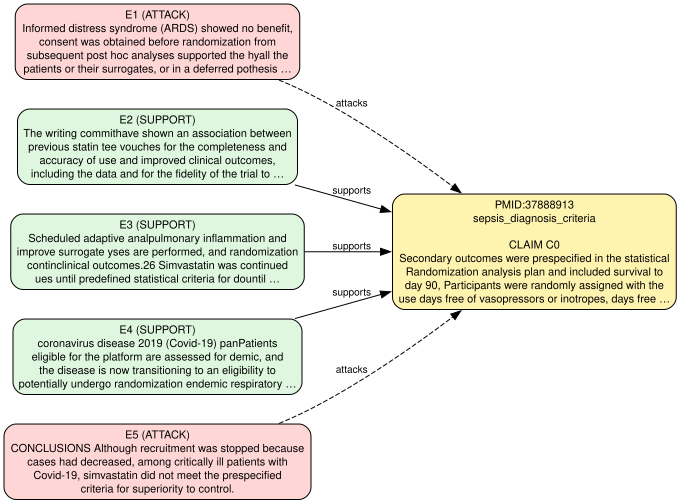

'Annane_Sepsis_Corpus\\out\\viz\\PMID_37888913.svg'

In [4]:
import json
import re
from pathlib import Path
from textwrap import fill

from graphviz import Digraph
from IPython.display import SVG, display

# 你项目里的目录变量通常已经有：PAPERS_DIR / OUT_DIR
# 如果没有，手动指定：
PAPERS_DIR = Path("Annane_Sepsis_Corpus/papers")
OUT_DIR = Path("Annane_Sepsis_Corpus/out")

VIZ_DIR = OUT_DIR / "viz"
VIZ_DIR.mkdir(parents=True, exist_ok=True)

def _shorten(s: str, width=55, max_lines=4):
    """换行+截断，避免节点太宽/太长"""
    s = re.sub(r"\s+", " ", (s or "").strip())
    if not s:
        return ""
    wrapped = fill(s, width=width)
    lines = wrapped.split("\n")
    if len(lines) > max_lines:
        lines = lines[:max_lines]
        lines[-1] = lines[-1].rstrip() + " …"
    return "\n".join(lines)

def render_argument_tree_json(tree: dict, out_path: Path, fmt="svg", show=True):
    """
    tree: argument_tree.json 的 dict
    out_path: 不带后缀的输出路径（graphviz 会自己加 .svg/.png）
    """
    paper_id = tree.get("paper_id", "UNKNOWN")
    topic = tree.get("topic", "UNKNOWN")
    root = tree.get("root") or {}

    g = Digraph(comment=paper_id, format=fmt)
    # 整体风格（你可以按喜好调）
    g.attr(rankdir="LR", splines="spline", nodesep="0.4", ranksep="0.6")
    g.attr("node", shape="box", style="rounded,filled", fontname="Helvetica", fontsize="11")
    g.attr("edge", fontname="Helvetica", fontsize="10")

    # --- Claim 节点 ---
    claim_id = root.get("id", "C0")
    claim_text = root.get("text") or (root.get("source") or {}).get("quote","")
    claim_label = f"{paper_id}\n{topic}\n\nCLAIM {claim_id}\n{_shorten(claim_text)}"
    g.node("C0", label=claim_label, fillcolor="#FFF3B0")  # 淡黄

    # --- Evidence 节点 + 边 ---
    children = root.get("children") or []
    for ch in children:
        eid = ch.get("id", "E?")
        pol = (ch.get("polarity") or "support").lower()
        ev_text = ch.get("text") or (ch.get("source") or {}).get("quote","")

        ev_label = f"{eid} ({pol.upper()})\n{_shorten(ev_text)}"

        # 节点颜色：support=淡绿，attack=淡红，其他=灰
        if pol == "attack":
            color = "#FFD6D6"
            edge_label = "attacks"
            edge_style = "dashed"
        elif pol == "support":
            color = "#DFF7DF"
            edge_label = "supports"
            edge_style = "solid"
        else:
            color = "#EEEEEE"
            edge_label = pol
            edge_style = "solid"

        g.node(eid, label=ev_label, fillcolor=color)

        # 注意：你当前 JSON 是 Evidence 作为 child，指向 Claim 的关系更直观（Evidence -> Claim）
        g.edge(eid, "C0", label=edge_label, style=edge_style)

    # 输出文件
    out_file = g.render(str(out_path), cleanup=True)

    if show and fmt == "svg":
        display(SVG(filename=out_file))

    return out_file

def load_argument_tree(paper_dir: Path):
    p = paper_dir / "argument_tree.json"
    if not p.exists():
        return None
    return json.loads(p.read_text(encoding="utf-8"))

def viz_one_paper(paper_dir: Path, fmt="svg", show=True):
    tree = load_argument_tree(paper_dir)
    if not tree:
        print("No argument_tree.json in", paper_dir)
        return None
    paper_id = tree.get("paper_id", paper_dir.name)
    out_path = VIZ_DIR / f"{paper_id.replace(':','_')}"
    return render_argument_tree_json(tree, out_path=out_path, fmt=fmt, show=show)

def viz_batch(limit=10, fmt="svg"):
    cnt = 0
    for p in sorted(PAPERS_DIR.glob("PMID_*")):
        if (p / "argument_tree.json").exists():
            print("Visualizing:", p.name)
            viz_one_paper(p, fmt=fmt, show=False)
            cnt += 1
            if cnt >= limit:
                break
    print("Done. Wrote to:", VIZ_DIR.resolve())

# ✅ 单篇：找到一个你想看的 paper_dir 传进去
#paper_dir, obj = get_first_ready_paper()
#viz_one_paper(paper_dir, fmt="svg", show=True)
def viz_by_pmid(pmid: str, fmt="svg", show=True):
    """
    pmid: 不带 PMID: 前缀，例如 "15025773"
    """
    paper_dir = PAPERS_DIR / f"PMID_{pmid}"
    if not paper_dir.exists():
        print("❌ Paper not found:", paper_dir)
        return None

    tree_path = paper_dir / "argument_tree.json"
    if not tree_path.exists():
        print("❌ argument_tree.json not found. Run extraction first.")
        return None

    tree = json.loads(tree_path.read_text(encoding="utf-8"))

    out_path = VIZ_DIR / f"PMID_{pmid}"
    return render_argument_tree_json(tree, out_path=out_path, fmt=fmt, show=show)

viz_by_pmid("37888913")

# ✅ 批量：生成前 N 篇 svg 到 out/viz
#viz_batch(limit=20, fmt="svg")

🎨 测试嵌套论证树可视化

📄 Paper: PMID:37888913
📝 Topic: sepsis_diagnosis_criteria
📊 Evidence 数量: 2
🔗 最大深度: 2 层

🎨 渲染中...


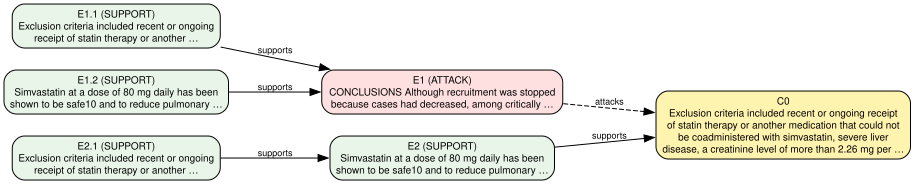

✅ 成功！保存位置: Annane_Sepsis_Corpus\out\viz\PMID_37888913_nested.svg


In [20]:
# ========== 完整可视化测试=========

import json
import re
from pathlib import Path
from graphviz import Digraph
from textwrap import fill
from IPython.display import SVG, display

# --- 1. 定义可视化函数（完整自包含版本）---
def render_nested_tree(tree: dict, out_path, fmt="svg", show=True):
    """
    渲染嵌套论证树（支持多层）
    """
    paper_id = tree.get("paper_id", "UNKNOWN")
    topic = tree.get("topic", "UNKNOWN")
    
    g = Digraph(comment=paper_id, format=fmt)
    g.attr(rankdir="LR", splines="spline", nodesep="0.3", ranksep="0.8")
    g.attr("node", shape="box", style="rounded,filled", fontname="Helvetica", fontsize="10")
    g.attr("edge", fontname="Helvetica", fontsize="9")
    
    def _shorten(s: str, width=50, max_lines=3):
        """截断并换行"""
        s = re.sub(r"\s+", " ", (s or "").strip())
        if not s:
            return ""
        wrapped = fill(s, width=width)
        lines = wrapped.split("\n")
        if len(lines) > max_lines:
            lines = lines[:max_lines]
            lines[-1] = lines[-1].rstrip() + " …"
        return "\n".join(lines)
    
    def render_node(node, parent_id=None, depth=0):
        """递归渲染节点"""
        nid = node.get("id", "?")
        ntype = (node.get("type") or "evidence").lower()
        pol = (node.get("polarity") or "").lower()
        text = node.get("text") or ""
        
        # 🎨 根据深度和类型设置样式
        if ntype == "claim":
            color = "#FFF3B0"  # 淡黄色
            width = 55
            max_lines = 4
        elif depth == 0:  # 一级 evidence
            color = "#FFD6D6" if pol == "attack" else "#DFF7DF"
            width = 50
            max_lines = 3
        else:  # 子证据（depth >= 1）
            color = "#FFE0E0" if pol == "attack" else "#E8F5E8"
            width = 45
            max_lines = 2
        
        # 标签
        label = f"{nid}"
        if pol:
            label += f" ({pol.upper()})"
        label += f"\n{_shorten(text, width=width, max_lines=max_lines)}"
        
        g.node(nid, label=label, fillcolor=color)
        
        # 🔗 连接到父节点
        if parent_id:
            edge_style = "dashed" if pol == "attack" else "solid"
            edge_label = "attacks" if pol == "attack" else "supports"
            g.edge(nid, parent_id, label=edge_label, style=edge_style)
        
        # 🔄 递归渲染子节点
        for child in node.get("children", []):
            render_node(child, parent_id=nid, depth=depth+1)
    
    # 渲染根节点
    root = tree.get("root", {})
    if not root:
        print("❌ 错误：树结构中没有 root 节点")
        return None
    
    render_node(root, parent_id=None, depth=0)
    
    # 输出文件
    try:
        out_file = g.render(str(out_path), cleanup=True)
        if show and fmt == "svg":
            display(SVG(filename=out_file))
        return out_file
    except Exception as e:
        print(f"❌ 渲染失败: {repr(e)}")
        return None


# --- 2. 测试可视化 ---
print("🎨 测试嵌套论证树可视化\n")

# 选择一个已生成的树文件
paper_dir = PAPERS_DIR / "PMID_37888913"
tree_file = paper_dir / "argument_tree_nested.json"

# 检查文件是否存在
if not tree_file.exists():
    print(f"❌ 文件不存在: {tree_file}")
    print("💡 请先运行嵌套抽取生成树文件")
else:
    # 加载树
    tree_nested = json.loads(tree_file.read_text(encoding="utf-8"))
    
    print(f"📄 Paper: {tree_nested.get('paper_id')}")
    print(f"📝 Topic: {tree_nested.get('topic')}")
    
    # 检查树结构
    root = tree_nested.get("root", {})
    if not root:
        print("❌ 树结构错误：没有 root 节点")
    else:
        n_evidence = len(root.get("children", []))
        print(f"📊 Evidence 数量: {n_evidence}")
        
        # 统计嵌套层数
        max_depth = 0
        def count_depth(node, depth=0):
            global max_depth
            max_depth = max(max_depth, depth)
            for child in node.get("children", []):
                count_depth(child, depth+1)
        
        count_depth(root)
        print(f"🔗 最大深度: {max_depth} 层")
        
        # 渲染
        paper_id = tree_nested.get("paper_id", "UNKNOWN")
        viz_path = VIZ_DIR / f"{paper_id.replace(':', '_')}_nested"
        
        print(f"\n🎨 渲染中...")
        out_file = render_nested_tree(tree_nested, viz_path, fmt="svg", show=True)
        
        if out_file:
            print(f"✅ 成功！保存位置: {out_file}")
        else:
            print("❌ 渲染失败")

In [ ]:
!pip install graphviz

In [21]:
# ========== 批量生成嵌套论证树 ==========

import json
from pathlib import Path

print("🚀 开始批量处理嵌套论证树\n")

# 配置
BATCH_SIZE = 20  # 处理数量（先测试几篇，确认无误后改成 999）
OUT_JSONL_NESTED = OUT_DIR / "argument_trees_nested.jsonl"

ok_cnt, fail_cnt = 0, 0
results_summary = []

with OUT_JSONL_NESTED.open("w", encoding="utf-8") as f:
    for paper_dir, obj, text in list(iter_ready_papers())[:BATCH_SIZE]:
        paper_id = f"PMID:{obj.get('pmid', 'UNKNOWN')}"
        topic = obj.get("topic", "UNKNOWN")
        
        print(f"\n{'='*60}")
        print(f"📄 Processing: {paper_id}")
        print(f"📝 Topic: {topic}")
        
        try:
            # 1. 抽取嵌套论证
            q_obj = pick_quotes_nested(
                paper_id, topic, text,
                max_sents=200,
                max_evidence=8,
                depth=2,  # 🆕 嵌套2层
                use_gemma=True,
                min_sa=2,
                min_pool_abstract=6
            )
            
            # 统计
            n_evidence = len(q_obj.get("evidence_quotes", []))
            n_attack = sum(1 for p in q_obj.get("polarities", []) if p == "attack")
            n_support = sum(1 for p in q_obj.get("polarities", []) if p == "support")
            n_nested = sum(len(n["children"]) for n in q_obj.get("nested_evidence", []))
            
            print(f"✅ Evidence: {n_evidence} ({n_support}S / {n_attack}A)")
            print(f"🔗 子证据: {n_nested} 条")
            
            # 2. 构建树
            tree = build_tree_from_quotes_nested(paper_id, topic, q_obj)
            
            # 3. 验证
            ok, msg = validate_tree_nested(tree)
            if not ok:
                raise ValueError(f"树验证失败: {msg}")
            
            # 4. 保存到单独文件
            (paper_dir / "argument_tree_nested.json").write_text(
                json.dumps(tree, ensure_ascii=False, indent=2),
                encoding="utf-8"
            )
            
            # 5. 追加到 JSONL
            f.write(json.dumps(tree, ensure_ascii=False) + "\n")
            f.flush()
            
            # 6. 可视化
            viz_path = VIZ_DIR / f"{paper_id.replace(':', '_')}_nested"
            render_nested_tree(tree, viz_path, fmt="svg", show=False)
            
            ok_cnt += 1
            results_summary.append({
                "paper_id": paper_id,
                "status": "ok",
                "n_evidence": n_evidence,
                "n_attack": n_attack,
                "n_support": n_support,
                "n_nested": n_nested
            })
            
            print(f"✅ OK")
            
        except Exception as e:
            fail_cnt += 1
            results_summary.append({
                "paper_id": paper_id,
                "status": "fail",
                "error": str(e)[:100]
            })
            print(f"❌ FAIL: {repr(e)}")

# ========== 汇总报告 ==========
print(f"\n{'='*60}")
print(f"🎉 批量处理完成！")
print(f"   成功: {ok_cnt} 篇")
print(f"   失败: {fail_cnt} 篇")
print(f"   总计: {ok_cnt + fail_cnt} 篇")

# 统计分析
if ok_cnt > 0:
    avg_evidence = sum(r["n_evidence"] for r in results_summary if r["status"] == "ok") / ok_cnt
    avg_attack = sum(r["n_attack"] for r in results_summary if r["status"] == "ok") / ok_cnt
    avg_nested = sum(r["n_nested"] for r in results_summary if r["status"] == "ok") / ok_cnt
    
    print(f"\n📊 平均统计:")
    print(f"   Evidence 数量: {avg_evidence:.1f} 条/篇")
    print(f"   Attack 数量: {avg_attack:.1f} 条/篇")
    print(f"   子证据数量: {avg_nested:.1f} 条/篇")

print(f"\n💾 输出文件:")
print(f"   JSONL: {OUT_JSONL_NESTED}")
print(f"   SVG: {VIZ_DIR}/*_nested.svg")

# 失败列表
if fail_cnt > 0:
    print(f"\n❌ 失败论文:")
    for r in results_summary:
        if r["status"] == "fail":
            print(f"   {r['paper_id']}: {r.get('error', 'unknown')}")

🚀 开始批量处理嵌套论证树


📄 Processing: PMID:15025773
📝 Topic: steroid_sensitivity
✅ Evidence: 3 (1S / 2A)
🔗 子证据: 7 条
✅ OK

📄 Processing: PMID:23361625
📝 Topic: sepsis_diagnosis_criteria
✅ Evidence: 5 (3S / 2A)
🔗 子证据: 12 条
✅ OK

📄 Processing: PMID:26633262
📝 Topic: steroid_sensitivity
✅ Evidence: 1 (1S / 0A)
🔗 子证据: 1 条
✅ OK

📄 Processing: PMID:26903338
📝 Topic: sepsis_diagnosis_criteria
✅ Evidence: 3 (2S / 1A)
🔗 子证据: 7 条
✅ OK

📄 Processing: PMID:27379022
📝 Topic: steroid_sensitivity
✅ Evidence: 4 (0S / 0A)
🔗 子证据: 0 条
✅ OK

📄 Processing: PMID:29025194
📝 Topic: sepsis_diagnosis_criteria
✅ Evidence: 4 (0S / 0A)
🔗 子证据: 0 条
✅ OK

📄 Processing: PMID:30105022
📝 Topic: sepsis_diagnosis_criteria
✅ Evidence: 4 (0S / 0A)
🔗 子证据: 0 条
✅ OK

📄 Processing: PMID:30111341
📝 Topic: sepsis_diagnosis_criteria
✅ Evidence: 2 (2S / 0A)
🔗 子证据: 2 条
✅ OK

📄 Processing: PMID:33150472
📝 Topic: sepsis_treatment_plan
✅ Evidence: 6 (3S / 3A)
🔗 子证据: 12 条
✅ OK

📄 Processing: PMID:33159530
📝 Topic: sepsis_diagnosis_criteria
✅ Evi

## Step5：jsonl → nodes.tsv / edges.tsv

## Step6：导出 RDF Turtle（TTL），用于截图的 RDF 可视化工具

## Step 7 Visualization

In [ ]:
# 一次性安装（notebook里跑）
!pip -q install graphviz

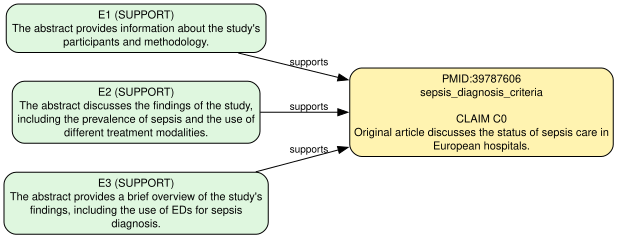

'out\\viz\\PMID_39787606.svg'

In [1]:
import json
import re
from pathlib import Path
from textwrap import fill

from graphviz import Digraph
from IPython.display import SVG, display

# 你项目里的目录变量通常已经有：PAPERS_DIR / OUT_DIR
# 如果没有，手动指定：
PAPERS_DIR = Path("papers")
OUT_DIR = Path("out")

VIZ_DIR = OUT_DIR / "viz"
VIZ_DIR.mkdir(parents=True, exist_ok=True)

def _shorten(s: str, width=55, max_lines=4):
    """换行+截断，避免节点太宽/太长"""
    s = re.sub(r"\s+", " ", (s or "").strip())
    if not s:
        return ""
    wrapped = fill(s, width=width)
    lines = wrapped.split("\n")
    if len(lines) > max_lines:
        lines = lines[:max_lines]
        lines[-1] = lines[-1].rstrip() + " …"
    return "\n".join(lines)

def render_argument_tree_json(tree: dict, out_path: Path, fmt="svg", show=True):
    """
    tree: argument_tree.json 的 dict
    out_path: 不带后缀的输出路径（graphviz 会自己加 .svg/.png）
    """
    paper_id = tree.get("paper_id", "UNKNOWN")
    topic = tree.get("topic", "UNKNOWN")
    root = tree.get("root") or {}

    g = Digraph(comment=paper_id, format=fmt)
    # 整体风格（你可以按喜好调）
    g.attr(rankdir="LR", splines="spline", nodesep="0.4", ranksep="0.6")
    g.attr("node", shape="box", style="rounded,filled", fontname="Helvetica", fontsize="11")
    g.attr("edge", fontname="Helvetica", fontsize="10")

    # --- Claim 节点 ---
    claim_id = root.get("id", "C0")
    claim_text = root.get("text") or (root.get("source") or {}).get("quote","")
    claim_label = f"{paper_id}\n{topic}\n\nCLAIM {claim_id}\n{_shorten(claim_text)}"
    g.node("C0", label=claim_label, fillcolor="#FFF3B0")  # 淡黄

    # --- Evidence 节点 + 边 ---
    children = root.get("children") or []
    for ch in children:
        eid = ch.get("id", "E?")
        pol = (ch.get("polarity") or "support").lower()
        ev_text = ch.get("text") or (ch.get("source") or {}).get("quote","")

        ev_label = f"{eid} ({pol.upper()})\n{_shorten(ev_text)}"

        # 节点颜色：support=淡绿，attack=淡红，其他=灰
        if pol == "attack":
            color = "#FFD6D6"
            edge_label = "attacks"
            edge_style = "dashed"
        elif pol == "support":
            color = "#DFF7DF"
            edge_label = "supports"
            edge_style = "solid"
        else:
            color = "#EEEEEE"
            edge_label = pol
            edge_style = "solid"

        g.node(eid, label=ev_label, fillcolor=color)

        # 注意：你当前 JSON 是 Evidence 作为 child，指向 Claim 的关系更直观（Evidence -> Claim）
        g.edge(eid, "C0", label=edge_label, style=edge_style)

    # 输出文件
    out_file = g.render(str(out_path), cleanup=True)

    if show and fmt == "svg":
        display(SVG(filename=out_file))

    return out_file

def load_argument_tree(paper_dir: Path):
    p = paper_dir / "argument_tree.json"
    if not p.exists():
        return None
    return json.loads(p.read_text(encoding="utf-8"))

def viz_one_paper(paper_dir: Path, fmt="svg", show=True):
    tree = load_argument_tree(paper_dir)
    if not tree:
        print("No argument_tree.json in", paper_dir)
        return None
    paper_id = tree.get("paper_id", paper_dir.name)
    out_path = VIZ_DIR / f"{paper_id.replace(':','_')}"
    return render_argument_tree_json(tree, out_path=out_path, fmt=fmt, show=show)

def viz_batch(limit=10, fmt="svg"):
    cnt = 0
    for p in sorted(PAPERS_DIR.glob("PMID_*")):
        if (p / "argument_tree.json").exists():
            print("Visualizing:", p.name)
            viz_one_paper(p, fmt=fmt, show=False)
            cnt += 1
            if cnt >= limit:
                break
    print("Done. Wrote to:", VIZ_DIR.resolve())

# ✅ 单篇：找到一个你想看的 paper_dir 传进去
#paper_dir, obj = get_first_ready_paper()
#viz_one_paper(paper_dir, fmt="svg", show=True)
def viz_by_pmid(pmid: str, fmt="svg", show=True):
    """
    pmid: 不带 PMID: 前缀，例如 "15025773"
    """
    paper_dir = PAPERS_DIR / f"PMID_{pmid}"
    if not paper_dir.exists():
        print("❌ Paper not found:", paper_dir)
        return None

    tree_path = paper_dir / "argument_tree.json"
    if not tree_path.exists():
        print("❌ argument_tree.json not found. Run extraction first.")
        return None

    tree = json.loads(tree_path.read_text(encoding="utf-8"))

    out_path = VIZ_DIR / f"PMID_{pmid}"
    return render_argument_tree_json(tree, out_path=out_path, fmt=fmt, show=show)

viz_by_pmid("39787606")

# ✅ 批量：生成前 N 篇 svg 到 out/viz
#viz_batch(limit=20, fmt="svg")

In [2]:
import json
import re
from pathlib import Path
from textwrap import fill

from graphviz import Digraph
from IPython.display import SVG, display

# 你项目里的目录变量通常已经有：PAPERS_DIR / OUT_DIR
# 如果没有，手动指定：
PAPERS_DIR = Path("papers")
OUT_DIR = Path("out")

VIZ_DIR = OUT_DIR / "viz"
VIZ_DIR.mkdir(parents=True, exist_ok=True)

def _shorten(s: str, width=55, max_lines=4):
    """换行+截断，避免节点太宽/太长"""
    s = re.sub(r"\s+", " ", (s or "").strip())
    if not s:
        return ""
    wrapped = fill(s, width=width)
    lines = wrapped.split("\n")
    if len(lines) > max_lines:
        lines = lines[:max_lines]
        lines[-1] = lines[-1].rstrip() + " …"
    return "\n".join(lines)

def render_argument_tree_json(tree: dict, out_path: Path, fmt="svg", show=True):
    """
    tree: argument_tree.json 的 dict
    out_path: 不带后缀的输出路径（graphviz 会自己加 .svg/.png）
    """
    paper_id = tree.get("paper_id", "UNKNOWN")
    topic = tree.get("topic", "UNKNOWN")
    root = tree.get("root") or {}

    g = Digraph(comment=paper_id, format=fmt)
    # 整体风格（你可以按喜好调）
    g.attr(rankdir="LR", splines="spline", nodesep="0.4", ranksep="0.6")
    g.attr("node", shape="box", style="rounded,filled", fontname="Helvetica", fontsize="11")
    g.attr("edge", fontname="Helvetica", fontsize="10")

    # --- Claim 节点 ---
    claim_id = root.get("id", "C0")
    claim_text = root.get("text") or (root.get("source") or {}).get("quote","")
    claim_label = f"{paper_id}\n{topic}\n\nCLAIM {claim_id}\n{_shorten(claim_text)}"
    g.node("C0", label=claim_label, fillcolor="#FFF3B0")  # 淡黄

    # --- Evidence 节点 + 边 ---
    children = root.get("children") or []
    for ch in children:
        eid = ch.get("id", "E?")
        pol = (ch.get("polarity") or "support").lower()
        ev_text = ch.get("text") or (ch.get("source") or {}).get("quote","")

        ev_label = f"{eid} ({pol.upper()})\n{_shorten(ev_text)}"

        # 节点颜色：support=淡绿，attack=淡红，其他=灰
        if pol == "attack":
            color = "#FFD6D6"
            edge_label = "attacks"
            edge_style = "dashed"
        elif pol == "support":
            color = "#DFF7DF"
            edge_label = "supports"
            edge_style = "solid"
        else:
            color = "#EEEEEE"
            edge_label = pol
            edge_style = "solid"

        g.node(eid, label=ev_label, fillcolor=color)

        # 注意：你当前 JSON 是 Evidence 作为 child，指向 Claim 的关系更直观（Evidence -> Claim）
        g.edge(eid, "C0", label=edge_label, style=edge_style)

    # 输出文件
    out_file = g.render(str(out_path), cleanup=True)

    if show and fmt == "svg":
        display(SVG(filename=out_file))

    return out_file

def load_argument_tree(paper_dir: Path):
    p = paper_dir / "argument_tree.json"
    if not p.exists():
        return None
    return json.loads(p.read_text(encoding="utf-8"))

def viz_one_paper(paper_dir: Path, fmt="svg", show=True):
    tree = load_argument_tree(paper_dir)
    if not tree:
        print("No argument_tree.json in", paper_dir)
        return None
    paper_id = tree.get("paper_id", paper_dir.name)
    out_path = VIZ_DIR / f"{paper_id.replace(':','_')}"
    return render_argument_tree_json(tree, out_path=out_path, fmt=fmt, show=show)

def viz_batch(limit=10, fmt="svg"):
    cnt = 0
    for p in sorted(PAPERS_DIR.glob("PMID_*")):
        if (p / "argument_tree.json").exists():
            print("Visualizing:", p.name)
            viz_one_paper(p, fmt=fmt, show=False)
            cnt += 1
            if cnt >= limit:
                break
    print("Done. Wrote to:", VIZ_DIR.resolve())

# ✅ 单篇：找到一个你想看的 paper_dir 传进去
#paper_dir, obj = get_first_ready_paper()
#viz_one_paper(paper_dir, fmt="svg", show=True)
"""

def viz_by_pmid(pmid: str, fmt="svg", show=True):
    
    #pmid: 不带 PMID: 前缀，例如 "15025773"
    
    paper_dir = PAPERS_DIR / f"PMID_{pmid}"
    if not paper_dir.exists():
        print("❌ Paper not found:", paper_dir)
        return None

    tree_path = paper_dir / "argument_tree.json"
    if not tree_path.exists():
        print("❌ argument_tree.json not found. Run extraction first.")
        return None

    tree = json.loads(tree_path.read_text(encoding="utf-8"))

    out_path = VIZ_DIR / f"PMID_{pmid}"
    return render_argument_tree_json(tree, out_path=out_path, fmt=fmt, show=show)

viz_by_pmid("26903338")
"""
# ✅ 批量：生成前 N 篇 svg 到 out/viz
viz_batch(limit=20, fmt="svg")

Visualizing: PMID_15025773
Visualizing: PMID_23361625
Visualizing: PMID_26633262
Visualizing: PMID_26903338
Visualizing: PMID_27379022
Visualizing: PMID_29025194
Visualizing: PMID_30105022
Visualizing: PMID_30111341
Visualizing: PMID_33150472
Visualizing: PMID_33159530
Visualizing: PMID_33876268
Visualizing: PMID_34351722
Visualizing: PMID_35708858
Visualizing: PMID_37176780
Visualizing: PMID_37888913
Visualizing: PMID_38250247
Visualizing: PMID_39787606
Visualizing: PMID_39905519
Visualizing: PMID_41180093
Done. Wrote to: D:\2026projects\courses-HoNLP\Annane_Sepsis_Corpus\out\viz


In [6]:
from pathlib import Path

CORPUS_DIR = Path(r"D:\2026projects\courses-HoNLP\Annane_Sepsis_Corpus\Annane_Sepsis_Corpus")
PAPERS_DIR = CORPUS_DIR / "papers"
OUT_DIR = CORPUS_DIR / "out"
VIZ_DIR = OUT_DIR / "viz_global"

print("CORPUS_DIR:", CORPUS_DIR)
print("PAPERS_DIR exists:", PAPERS_DIR.exists(), PAPERS_DIR)
OUT_DIR.mkdir(parents=True, exist_ok=True)
VIZ_DIR.mkdir(parents=True, exist_ok=True)
print("OUT_DIR:", OUT_DIR)
print("VIZ_DIR:", VIZ_DIR)

CORPUS_DIR: D:\2026projects\courses-HoNLP\Annane_Sepsis_Corpus\Annane_Sepsis_Corpus
PAPERS_DIR exists: True D:\2026projects\courses-HoNLP\Annane_Sepsis_Corpus\Annane_Sepsis_Corpus\papers
OUT_DIR: D:\2026projects\courses-HoNLP\Annane_Sepsis_Corpus\Annane_Sepsis_Corpus\out
VIZ_DIR: D:\2026projects\courses-HoNLP\Annane_Sepsis_Corpus\Annane_Sepsis_Corpus\out\viz_global


In [11]:
import json, re
from pathlib import Path

def strip_section_prefix(s: str) -> str:
    return re.sub(r"^\[[A-Z_]+\]\s*", "", (s or "").strip())

def extract_from_tree_obj(obj: dict, max_evidence=30, include_nested=False):
    """
    适配你的结构:
      obj["root"] = {type:"claim", text:..., children:[{type:"evidence", polarity:..., text:..., children:[]}, ...]}
    返回: claim_text, evidence_texts, polarities, (optional) nested_evidence
    """
    root = obj.get("root") or {}
    claim_text = strip_section_prefix(root.get("text") or "")
    if not claim_text:
        # 兜底：从 source.quote 拿
        claim_text = strip_section_prefix((root.get("source") or {}).get("quote") or "")

    evidence_texts = []
    polarities = []
    nested = []

    children = root.get("children") or []
    for ch in children:
        if ch.get("type") != "evidence":
            continue
        pol = (ch.get("polarity") or "irrelevant").lower()
        txt = strip_section_prefix(ch.get("text") or "")
        if not txt:
            txt = strip_section_prefix((ch.get("source") or {}).get("quote") or "")
        if not txt:
            continue

        evidence_texts.append(txt)
        polarities.append(pol)

        if include_nested:
            # 把子证据也捞出来（如果你之后要做更深层级的全局图）
            sub_children = ch.get("children") or []
            subs = []
            sub_pols = []
            for sc in sub_children:
                stxt = strip_section_prefix(sc.get("text") or "")
                if not stxt:
                    stxt = strip_section_prefix((sc.get("source") or {}).get("quote") or "")
                if stxt:
                    subs.append(stxt)
                    sub_pols.append((sc.get("polarity") or "irrelevant").lower())
            nested.append({"parent": txt, "children": subs, "polarities": sub_pols})

        if len(evidence_texts) >= max_evidence:
            break

    return claim_text, evidence_texts, polarities, nested

In [18]:
def rebuild_jsonl_from_papers_root_tree(PAPERS_DIR: Path, OUT_DIR: Path):
    out_jsonl = OUT_DIR / "argument_trees.jsonl"
    found, kept, bad = 0, 0, 0

    with out_jsonl.open("w", encoding="utf-8") as w:
        for d in sorted(PAPERS_DIR.glob("PMID_*")):
            p = d / "argument_tree.json"
            if not p.exists():
                continue
            found += 1
            try:
                obj = json.loads(p.read_text(encoding="utf-8"))
            except Exception as e:
                bad += 1
                print("⚠️ bad json:", p, repr(e))
                continue

            claim, evs, pols, _ = extract_from_tree_obj(obj, max_evidence=30, include_nested=False)
            if not claim or not evs:
                continue

            packed = {
                "paper_id": obj.get("paper_id") or d.name.replace("PMID_", ""),
                "topic": obj.get("topic") or "sepsis",
                "claim_quote": claim,
                "evidence_quotes": evs,
                "polarities": pols
            }
            w.write(json.dumps(packed, ensure_ascii=False) + "\n")
            kept += 1

    print("Found argument_tree.json:", found)
    print("Bad json:", bad)
    print("Wrote valid lines:", kept)
    print("✅ Rebuilt:", out_jsonl, "size:", out_jsonl.stat().st_size)

rebuild_jsonl_from_papers_root_tree(PAPERS_DIR, OUT_DIR)

Found argument_tree.json: 14
Bad json: 0
Wrote valid lines: 14
✅ Rebuilt: D:\2026projects\courses-HoNLP\Annane_Sepsis_Corpus\Annane_Sepsis_Corpus\out\argument_trees.jsonl size: 21492


In [19]:
trees = load_per_paper_trees(PAPERS_DIR, OUT_DIR)
print("Loaded trees:", len(trees))
print("Example:", trees[0]["paper_id"], trees[0]["topic"])
print("Claim head:", trees[0]["claim_quote"][:140])
print("Evs/pols:", len(trees[0]["evidence_quotes"]), len(trees[0]["polarities"]))

✅ Loading: D:\2026projects\courses-HoNLP\Annane_Sepsis_Corpus\Annane_Sepsis_Corpus\out\argument_trees.jsonl
Loaded trees: 14
Example: PMID:15025773 steroid_sensitivity
Claim head: These agents were commonly used to treat sepsis until the end of the 1980s, when several randomized trials casted serious doubt on any benef
Evs/pols: 1 1


In [20]:
def claim_is_reasonable(claim: str) -> bool:
    low = (claim or "").lower()
    if len(low) < 50:
        return False
    # 明显作者名单/标题拼接特征
    if low.count(",") >= 6:
        return False
    # 没出现 sepsis 语境关键词就很可疑
    if not any(k in low for k in ["sepsis", "septic", "shock", "infection", "mortality", "criteria", "recommend", "should", "guideline", "defined"]):
        return False
    return True

In [21]:
import json

def load_per_paper_trees(PAPERS_DIR: Path, OUT_DIR: Path):
    jsonl = OUT_DIR / "argument_trees.jsonl"
    items = []

    if jsonl.exists():
        print("✅ Loading:", jsonl)
        with jsonl.open("r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                items.append(json.loads(line))
        return items

    # fallback: scan each paper dir
    print("ℹ️ argument_trees.jsonl not found, scanning papers/*/argument_tree.json ...")
    for d in PAPERS_DIR.glob("PMID_*"):
        p = d / "argument_tree.json"
        if p.exists():
            try:
                items.append(json.loads(p.read_text(encoding="utf-8")))
            except Exception as e:
                print("⚠️ failed to read:", p, repr(e))
    return items

trees = load_per_paper_trees(PAPERS_DIR, OUT_DIR)
print("Loaded trees:", len(trees))
print("Keys example:", list(trees[0].keys()) if trees else None)

✅ Loading: D:\2026projects\courses-HoNLP\Annane_Sepsis_Corpus\Annane_Sepsis_Corpus\out\argument_trees.jsonl
Loaded trees: 14
Keys example: ['paper_id', 'topic', 'claim_quote', 'evidence_quotes', 'polarities']


## 把“每篇的 claim”做标准化（为了跨文献合并）

In [22]:
import re

def strip_section_prefix(s: str) -> str:
    # 去掉类似 "[ABSTRACT]" "[RESULTS]" 前缀
    return re.sub(r"^\[[A-Z_]+\]\s*", "", (s or "").strip())

def normalize_claim(s: str) -> str:
    s = strip_section_prefix(s)
    s = s.replace("\n", " ")
    s = re.sub(r"\s+", " ", s).strip().lower()
    # 可选：去掉多余引号
    s = s.strip(' "\'')
    return s

claims = []
meta = []  # 对应每条 claim 来自哪篇
for t in trees:
    paper_id = t.get("paper_id") or t.get("pmid") or "UNKNOWN"
    claim = t.get("claim_quote") or t.get("claim") or ""
    if not claim.strip():
        continue
    claims.append(normalize_claim(claim))
    meta.append({"paper_id": paper_id, "raw_claim": claim})

print("Claims collected:", len(claims))
print("Example:", claims[0][:160] if claims else None)

Claims collected: 14
Example: these agents were commonly used to treat sepsis until the end of the 1980s, when several randomized trials casted serious doubt on any benefit from high-dose gl


In [28]:
import json, re
from pathlib import Path

# --- 你已经有的话可复用；没有就放这里 ---
def strip_section_prefix(s: str) -> str:
    return re.sub(r"^\[[A-Z_]+\]\s*", "", (s or "").strip())

def normalize_claim(s: str) -> str:
    s = strip_section_prefix(s)
    s = s.replace("\n", " ")
    s = re.sub(r"\s+", " ", s).strip().lower()
    return s.strip(' "\'')

def extract_from_tree_obj(obj: dict, max_evidence=30):
    root = obj.get("root") or {}
    claim_text = strip_section_prefix(root.get("text") or "")
    if not claim_text:
        claim_text = strip_section_prefix((root.get("source") or {}).get("quote") or "")

    evs, pols = [], []
    for ch in (root.get("children") or []):
        if ch.get("type") != "evidence":
            continue
        pol = (ch.get("polarity") or "irrelevant").lower()
        txt = strip_section_prefix(ch.get("text") or "")
        if not txt:
            txt = strip_section_prefix((ch.get("source") or {}).get("quote") or "")
        if not txt:
            continue
        evs.append(txt)
        pols.append(pol)
        if len(evs) >= max_evidence:
            break
    return claim_text, evs, pols

claims = []
claim_meta = []  # ✅ 你后面要用的变量

for d in sorted(PAPERS_DIR.glob("PMID_*")):
    p = d / "argument_tree.json"
    if not p.exists():
        continue

    obj = json.loads(p.read_text(encoding="utf-8"))
    paper_id = obj.get("paper_id") or d.name.replace("PMID_", "")
    topic = obj.get("topic") or "sepsis"

    claim_raw, evs, pols = extract_from_tree_obj(obj, max_evidence=30)
    if not claim_raw.strip():
        continue

    claim_norm = normalize_claim(claim_raw)
    claims.append(claim_norm)
    claim_meta.append({
        "paper_id": paper_id,
        "topic": topic,
        "raw_claim": strip_section_prefix(claim_raw),
        "claim_norm": claim_norm,
        "evidence_quotes": evs,
        "polarities": pols,
    })

print("Collected claims:", len(claims))
print("Example claim:", claim_meta[0]["raw_claim"][:160] if claim_meta else None)
print("Example ev count:", len(claim_meta[0]["evidence_quotes"]) if claim_meta else None)

Collected claims: 14
Example claim: These agents were commonly used to treat sepsis until the end of the 1980s, when several randomized trials casted serious doubt on any benefit from high-dose gl
Example ev count: 1


## 对所有 claim 做聚类（把同义 claim 合并成“全局 claim 节点”）

A) 不装新模型：TF-IDF 聚类

In [37]:
import json
from pathlib import Path

OUT_DIR = Path(r"D:\2026projects\courses-HoNLP\Annane_Sepsis_Corpus\Annane_Sepsis_Corpus\out")
jsonl_path = OUT_DIR / "argument_trees.jsonl"

trees = []
with jsonl_path.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        trees.append(json.loads(line))

print("Loaded:", len(trees))
print("Example keys:", list(trees[0].keys()))
print("Example paper/topic:", trees[0]["paper_id"], trees[0]["topic"])

Loaded: 14
Example keys: ['paper_id', 'topic', 'claim_quote', 'evidence_quotes', 'polarities']
Example paper/topic: PMID:15025773 steroid_sensitivity


In [38]:
from collections import defaultdict
import re

def deglue(text: str) -> str:
    # 修复常见粘连：criteriaWe -> criteria We
    t = (text or "")
    t = re.sub(r"([a-z])([A-Z])", r"\1 \2", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

def norm_text(s: str) -> str:
    s = deglue(s).lower()
    s = re.sub(r"\s+", " ", s).strip()
    return s

topic_rec = defaultdict(lambda: {
    "papers": set(),
    "claims": [],        # list of (paper_id, claim)
    "support": [],       # list of (paper_id, evidence)
    "attack": [],
    "irrelevant": []
})

for t in trees:
    pid = t.get("paper_id","UNKNOWN")
    topic = t.get("topic","UNKNOWN")
    claim = deglue(t.get("claim_quote",""))

    topic_rec[topic]["papers"].add(pid)
    topic_rec[topic]["claims"].append((pid, claim))

    evs = t.get("evidence_quotes") or []
    pols = t.get("polarities") or []
    for ev, pol in zip(evs, pols):
        ev = deglue(ev)
        pol = (pol or "irrelevant").lower()
        if pol == "support":
            topic_rec[topic]["support"].append((pid, ev))
        elif pol == "attack":
            topic_rec[topic]["attack"].append((pid, ev))
        else:
            topic_rec[topic]["irrelevant"].append((pid, ev))

print("Topics:", len(topic_rec))
for k,v in topic_rec.items():
    print(k, "papers:", len(v["papers"]), "support:", len(v["support"]), "attack:", len(v["attack"]))

Topics: 3
steroid_sensitivity papers: 2 support: 2 attack: 0
sepsis_diagnosis_criteria papers: 8 support: 32 attack: 9
sepsis_treatment_plan papers: 4 support: 8 attack: 5


In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def cluster_by_threshold(texts, threshold=0.72):
    vec = TfidfVectorizer(ngram_range=(1,2), min_df=1, stop_words="english")
    X = vec.fit_transform(texts)
    S = cosine_similarity(X)

    n = len(texts)
    parent = list(range(n))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a,b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    for i in range(n):
        for j in range(i+1, n):
            if S[i, j] >= threshold:
                union(i, j)

    roots = {}
    cid = 0
    labels = [None]*n
    for i in range(n):
        r = find(i)
        if r not in roots:
            roots[r] = cid
            cid += 1
        labels[i] = roots[r]
    return labels

def claim_quality_penalty(s: str) -> float:
    """把明显不像 claim 的句子降权，用于选 canonical claim。"""
    low = (s or "").lower()
    bad = 0
    for pat in ["selection criteria","we included","randomization","supplementary appendix","reproduced with permission",
                "page ", "abstract management", "binding affinity", "ed95", "copyright", "doi"]:
        if pat in low:
            bad += 1
    # 标题/人名串（粗略）
    if low.count(",") >= 4:
        bad += 2
    return bad

def pick_canonical(claims):
    # 选一个更像“结论/定义/建议”的代表句：长度适中 + 不像方法学/标题
    scored = []
    for c in claims:
        c2 = deglue(c)
        score = 0.0
        if 60 <= len(c2) <= 240: score += 1.0
        for kw in ["should","recommend","defined","mortality","survival","sepsis","septic shock","corticosteroid","hydrocortisone"]:
            if kw in c2.lower():
                score += 1.0
        score -= 2.0 * claim_quality_penalty(c2)
        scored.append((score, c2))
    scored.sort(reverse=True, key=lambda x: x[0])
    return scored[0][1] if scored else ""

global_graph = {"topic_groups": []}

for topic, rec in topic_rec.items():
    claim_list = [c for _, c in rec["claims"]]
    # 同 topic 内聚类
    labels = cluster_by_threshold([norm_text(c) for c in claim_list], threshold=0.72)

    clusters = defaultdict(lambda: {
        "paper_ids": set(),
        "claims": [],
        "support": [],
        "attack": [],
        "irrelevant": []
    })

    # 建 paper -> 对应 evidence（从原 trees 取，避免 topic_rec 混合丢信息）
    trees_in_topic = [t for t in trees if t.get("topic")==topic]
    tree_by_pid = {t.get("paper_id","UNKNOWN"): t for t in trees_in_topic}

    for i, (pid, claim) in enumerate(rec["claims"]):
        cid = labels[i]
        clusters[cid]["paper_ids"].add(pid)
        clusters[cid]["claims"].append(claim)

        t = tree_by_pid.get(pid)
        if not t: 
            continue
        evs = t.get("evidence_quotes") or []
        pols = t.get("polarities") or []
        for ev, pol in zip(evs, pols):
            ev = deglue(ev)
            pol = (pol or "irrelevant").lower()
            if pol == "support":
                clusters[cid]["support"].append((pid, ev))
            elif pol == "attack":
                clusters[cid]["attack"].append((pid, ev))
            else:
                clusters[cid]["irrelevant"].append((pid, ev))

    # 组装 topic group 输出
    group = {"topic": topic, "clusters": []}
    for cid, c in clusters.items():
        canon = pick_canonical(c["claims"])
        group["clusters"].append({
            "cluster_id": cid,
            "canonical_claim": canon,
            "papers_count": len(c["paper_ids"]),
            "support_count": len(c["support"]),
            "attack_count": len(c["attack"]),
            "paper_ids": sorted(c["paper_ids"]),
            "support_examples": c["support"][:5],
            "attack_examples": c["attack"][:5],
        })

    # topic 内按“论文数+证据数”排序
    group["clusters"].sort(key=lambda x: (x["papers_count"], x["support_count"]+x["attack_count"]), reverse=True)
    global_graph["topic_groups"].append(group)

# topic 之间也排序：优先论文多的 topic
global_graph["topic_groups"].sort(key=lambda g: sum(c["papers_count"] for c in g["clusters"]), reverse=True)

print("Built global_graph topic_groups:", len(global_graph["topic_groups"]))

Built global_graph topic_groups: 3


In [40]:
#%pip -q install graphviz
from graphviz import Digraph
import textwrap
from pathlib import Path

VIZ_DIR = OUT_DIR / "viz_global"
VIZ_DIR.mkdir(parents=True, exist_ok=True)

def wrap(s, w=46):
    return "\n".join(textwrap.wrap((s or "").strip(), width=w))

def render_overview(global_graph, out_path: Path, top_topics=6, top_clusters_each=5):
    dot = Digraph("GLOBAL", format="svg")
    dot.attr(rankdir="TB")
    dot.attr("node", shape="box", style="rounded")

    for gi, group in enumerate(global_graph["topic_groups"][:top_topics], start=1):
        topic = group["topic"]
        topic_id = f"T{gi}"
        dot.node(topic_id, label=f"TOPIC\n{topic}")

        for c in group["clusters"][:top_clusters_each]:
            cid = f"{topic_id}_C{c['cluster_id']}"
            label = f"{wrap(c['canonical_claim'], 52)}\n\npapers={c['papers_count']}  support={c['support_count']}  attack={c['attack_count']}"
            dot.node(cid, label=label)
            dot.edge(topic_id, cid)

    return dot.render(str(out_path), cleanup=True)

overview_file = render_overview(global_graph, VIZ_DIR / "global_overview", top_topics=10, top_clusters_each=6)
print("✅ overview:", overview_file)

✅ overview: D:\2026projects\courses-HoNLP\Annane_Sepsis_Corpus\Annane_Sepsis_Corpus\out\viz_global\global_overview.svg


In [41]:
def render_cluster_detail(topic: str, cluster: dict, out_path: Path, k=3):
    dot = Digraph("DETAIL", format="svg")
    dot.attr(rankdir="LR")
    dot.attr("node", shape="box", style="rounded")

    claim_id = "CLAIM"
    dot.node(claim_id, label=f"TOPIC: {topic}\n\n{wrap(cluster['canonical_claim'], 60)}")

    # support
    for i, (pid, txt) in enumerate(cluster.get("support_examples", [])[:k], start=1):
        nid = f"S{i}"
        dot.node(nid, label=f"SUPPORT ({pid})\n{wrap(txt, 60)}")
        dot.edge(nid, claim_id, label="support")

    # attack
    for i, (pid, txt) in enumerate(cluster.get("attack_examples", [])[:k], start=1):
        nid = f"A{i}"
        dot.node(nid, label=f"ATTACK ({pid})\n{wrap(txt, 60)}")
        dot.edge(nid, claim_id, label="attack")

    return dot.render(str(out_path), cleanup=True)

# 给每个 topic 的 top1 cluster 出一张 detail
for group in global_graph["topic_groups"]:
    if not group["clusters"]:
        continue
    c0 = group["clusters"][0]
    fname = f"detail_{group['topic']}_C{c0['cluster_id']}".replace(":", "_").replace("/", "_")
    f = render_cluster_detail(group["topic"], c0, VIZ_DIR / fname, k=3)
    print("✅ detail:", f)

✅ detail: D:\2026projects\courses-HoNLP\Annane_Sepsis_Corpus\Annane_Sepsis_Corpus\out\viz_global\detail_sepsis_diagnosis_criteria_C0.svg
✅ detail: D:\2026projects\courses-HoNLP\Annane_Sepsis_Corpus\Annane_Sepsis_Corpus\out\viz_global\detail_sepsis_treatment_plan_C0.svg
✅ detail: D:\2026projects\courses-HoNLP\Annane_Sepsis_Corpus\Annane_Sepsis_Corpus\out\viz_global\detail_steroid_sensitivity_C0.svg


# ==========================================
# GLOBAL_V2: 三主题论证整合
# ==========================================

In [ ]:
import re

THEME_MAP = {
    "symptoms_diagnosis": [
        "diagnosis", "criteria", "definition", "screen", "qsofa", "sofa", "lactate", "procalcitonin", "pct"
    ],
    "treatment_recommendation": [
        "treatment", "management", "therapy", "plan", "antibiotic", "vasopressor", "fluid", "hydrocortisone", "steroid",
        "anticoagulation", "statin", "nmba", "ventilation", "ards"
    ],
    "sequelae_prevention": [
        "prevention", "sequelae", "follow-up", "long-term", "rehabilitation", "secondary infection", "complication",
        "quality improvement", "stewardship"
    ]
}

def assign_theme(topic: str, claim: str = "") -> str:
    t = (topic or "").lower()
    c = (claim or "").lower()
    hay = t + " " + c
    for theme, kws in THEME_MAP.items():
        if any(k in hay for k in kws):
            return theme
    # 如果无法判断，按治疗建议（通常最多）
    return "treatment_recommendation"

In [43]:
def deglue(text: str) -> str:
    t = (text or "")
    t = re.sub(r"([a-z])([A-Z])", r"\1 \2", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

BAD_CLAIM_PATTERNS = [
    r"\breproduced with permission\b",
    r"\bstatistical analysis plan\b|\brandomization\b|\bparticipants were randomly\b",
    r"\bwe included\b|\bselection criteria\b|\bmethods?\b|\bmaterials?\b",
    r"\bdoi\b|\bissn\b|\bpage \d+\b|\bcommittee\b|\binformed consent\b",
]

def is_bad_claim(s: str) -> bool:
    low = (s or "").lower()
    if len(low) < 40:
        return True
    return any(re.search(p, low) for p in BAD_CLAIM_PATTERNS)

In [ ]:
SYMPTOM_DIAG_CUES = [
    "should be defined", "is defined", "defined as", "criteria", "diagnos", "screen", "qsofa", "sofa",
    "organ dysfunction", "lactate", "infection", "septic shock", "sepsis-3", "procalcitonin", "pct"
]
TREATMENT_CUES = [
    "we recommend", "should", "recommend", "suggest", "administer", "treat", "therapy", "management",
    "hydrocortisone", "corticosteroid", "vasopressor", "norepinephrine", "fluid resuscitation",
    "antibiotic", "source control", "anticoagulation", "ventilation"
]
SEQUELAE_PREV_CUES = [
    "prevention", "prevent", "follow-up", "long-term", "sequelae", "rehabilitation", "secondary infection",
    "stewardship", "quality improvement", "screening", "early detection", "implementation"
]

def claim_score_by_theme(s: str, theme: str) -> float:
    s = deglue(s)
    low = s.lower()
    sc = 0.0

    # 基础：sepsis语境
    if any(k in low for k in ["sepsis", "septic", "septic shock", "infection", "icu"]):
        sc += 1.5

    # 命题性：包含 should/defined/recommend 之类
    if any(k in low for k in ["should", "defined", "recommend", "suggest", "associated", "reduce", "increase", "no benefit"]):
        sc += 1.5

    # 主题加权
    cues = SYMPTOM_DIAG_CUES if theme == "symptoms_diagnosis" else \
           TREATMENT_CUES if theme == "treatment_recommendation" else \
           SEQUELAE_PREV_CUES
    for kw in cues:
        if kw in low:
            sc += 2.0

    # 惩罚坏句
    if is_bad_claim(s):
        sc -= 6.0

    # 长度适中加分
    if 60 <= len(s) <= 240:
        sc += 1.0
    if len(s) > 360:
        sc -= 2.0

    return sc

def repick_claim_for_tree(t: dict, theme: str) -> str:
    # 候选：claim_quote + evidence_quotes
    cands = []
    c0 = t.get("claim_quote") or ""
    if c0.strip():
        cands.append(c0)
    cands.extend(t.get("evidence_quotes") or [])

    cands = [deglue(x) for x in cands if x and len(deglue(x)) >= 40]
    # 去重
    seen, uniq = set(), []
    for x in cands:
        k = x.lower()
        if k in seen: 
            continue
        seen.add(k)
        uniq.append(x)

    if not uniq:
        return deglue(c0)

    scored = sorted([(claim_score_by_theme(x, theme), x) for x in uniq], reverse=True, key=lambda z: z[0])
    # 选第一个不是坏句的；否则退回最高分
    for _, x in scored[:12]:
        if not is_bad_claim(x):
            return x
    return scored[0][1]

In [ ]:
import re

# -----------------------------
# 0) 基础清洗
# -----------------------------
def deglue(text: str) -> str:
    t = (text or "")
    t = re.sub(r"([a-z])([A-Z])", r"\1 \2", t)   # criteriaWe -> criteria We
    t = re.sub(r"\s+", " ", t).strip()
    return t

def norm(s: str) -> str:
    s = deglue(s).lower()
    s = re.sub(r"\s+", " ", s).strip()
    return s

# -----------------------------
# 1) 主题关键词：用于“相关性门控”
# -----------------------------
THEME_KW = {
    "symptoms_diagnosis": [
        "defined", "definition", "criteria", "diagnos", "screen",
        "qsofa", "sofa", "lactate", "procalcitonin", "pct",
        "organ dysfunction", "infection", "septic shock", "sepsis-3"
    ],
    "treatment_recommendation": [
        "recommend", "should", "suggest", "treat", "therapy", "management",
        "hydrocortisone", "corticosteroid", "steroid",
        "vasopressor", "norepinephrine", "fluid resuscitation",
        "antibiotic", "source control",
        "dose", "duration", "infusion", "bolus"
    ],
    "sequelae_prevention": [
        "long-term", "follow-up", "sequelae", "rehabilitation",
        "prevention", "prevent", "secondary infection", "complication",
        "stewardship", "quality improvement", "implementation"
    ]
}

# -----------------------------
# 2) 更可靠的 support / attack 线索（强/弱分层）
# -----------------------------
SUPPORT_STRONG = [
    "reduced mortality", "reduce mortality", "improved survival", "improve survival",
    "improved outcomes", "improve outcomes", "beneficial", "effective",
    "associated with lower", "was associated with lower",
    "shock reversal", "shorter icu stay", "shorter hospital stay",
    "strong recommendation", "we recommend", "should be used", "is recommended",
    "most likely achievable", "optimal results", "led to a reconsideration"
]
SUPPORT_WEAK = [
    "may improve", "could improve", "suggest", "appears to", "likely",
    "supported the hypothesis", "favorable", "better", "advantage"
]

ATTACK_STRONG = [
    "no benefit", "did not improve", "did not reduce", "no significant difference",
    "failed to", "ineffective", "harm", "adverse", "worse",
    "increased mortality", "increase mortality", "higher mortality",
    "not recommended", "should not", "contraindicated",
    "casted serious doubt", "serious doubt"
]
ATTACK_WEAK = [
    "uncertain", "controversial", "limited evidence", "low quality evidence",
    "insufficient evidence", "drawbacks", "concern", "risk of"
]

# -----------------------------
# 3) 句子是否值得判 polarity（过滤背景/流程/出版噪声）
# -----------------------------
EVIDENCE_BAD = [
    "reproduced with permission", "statistical analysis plan", "informed consent",
    "committee", "supplementary appendix", "doi", "issn", "page ",
    "writing committee", "protocol", "randomization continued"
]

def is_evidence_noise(ev: str) -> bool:
    low = norm(ev)
    if len(low) < 50:
        return True
    return any(x in low for x in EVIDENCE_BAD)

BACKGROUND_CUES = [
    "we present a summary", "we present", "we summarize", "narrative review",
    "study selection", "risk of bias", "rob", "grading of recommendations", "grade",
    "statistical analysis plan", "randomization", "informed consent", "writing committee",
    "supplementary appendix", "protocol", "committee"
]

def is_background_or_methods(ev: str) -> bool:
    e = norm(ev)
    return any(k in e for k in BACKGROUND_CUES)

def theme_relevant(claim: str, ev: str, theme: str) -> bool:
    """
    - 必须命中 >=2 个主题关键词（避免 anticoagulation 混入 diagnosis）
    - 允许 sepsis 语境做弱兜底，但仍需至少命中 1 个主题词
    """
    text = norm((claim or "") + " " + (ev or ""))
    kws = THEME_KW.get(theme, [])
    hit = sum(1 for k in kws if k in text)

    has_sepsis_context = ("sepsis" in text or "septic" in text or "septic shock" in text)

    if hit >= 2:
        return True
    if hit >= 1 and has_sepsis_context:
        return True
    return False

# -----------------------------
# 4) polarity 主函数：先相关性门控，再强线索，再弱线索，最后 irrelevant
# -----------------------------
def infer_polarity_final(claim: str, evidence: str, theme: str) -> str:
    # 1) 噪声
    if is_evidence_noise(evidence):
        return "irrelevant"

    # 2) 背景/方法学句：直接 irrelevant
    if is_background_or_methods(evidence):
        return "irrelevant"

    # 3) 主题门控
    if not theme_relevant(claim, evidence, theme):
        return "irrelevant"

    e = norm(evidence)

    # 4) 先 strong cue
    if any(k in e for k in ATTACK_STRONG):
        return "attack"
    if any(k in e for k in SUPPORT_STRONG):
        return "support"

    # 5) 再 weak cue
    if any(k in e for k in ATTACK_WEAK):
        return "attack"
    if any(k in e for k in SUPPORT_WEAK):
        return "support"

    return "irrelevant"

In [61]:
EVID_CUES = {
    "symptoms_diagnosis": [
        "defined", "definition", "criteria", "qsofa", "sofa", "lactate", "screen", "sensitivity", "specificity",
        "delphi", "consensus", "task force"
    ],
    "treatment_recommendation": [
        "randomized", "trial", "meta-analysis", "systematic review",
        "mortality", "survival", "shock reversal", "outcome", "hazard", "risk",
        "dose", "duration", "administer", "recommend", "should"
    ],
    "sequelae_prevention": [
        "long-term", "follow-up", "sequelae", "rehabilitation", "prevention", "prevent",
        "secondary infection", "complication", "quality improvement", "implementation", "stewardship"
    ]
}

EVID_BAD = [
    "reproduced with permission", "statistical analysis plan", "informed consent", "committee",
    "doi", "issn", "page ", "copyright"
]

def evidence_ok(ev: str, theme: str) -> bool:
    ev = deglue(ev)
    low = ev.lower()
    if len(ev) < 50:
        return False
    if any(b in low for b in EVID_BAD):
        return False
    cues = EVID_CUES[theme]
    return any(k in low for k in cues) or ("sepsis" in low or "septic" in low)

def select_top_evidence_v2(t: dict, theme: str, k_support=3, k_attack=3):
    claim = deglue(t.get("claim_quote",""))
    evs = [deglue(x) for x in (t.get("evidence_quotes") or [])]

    # 先按噪声过滤
    evs = [e for e in evs if e and not is_evidence_noise(e)]

    # 用最终 polarity 模块重算
    sup, atk = [], []
    for e in evs:
        pol = infer_polarity_final(claim, e, theme)
        if pol == "support":
            sup.append(e)
        elif pol == "attack":
            atk.append(e)

    # 排序：优先强线索句（出现 strong cue 的排前面）
    def strength_score(e: str) -> int:
        el = norm(e)
        s = 0
        s += 2 * sum(1 for k in SUPPORT_STRONG if k in el)
        s += 1 * sum(1 for k in SUPPORT_WEAK if k in el)
        s += 2 * sum(1 for k in ATTACK_STRONG if k in el)
        s += 1 * sum(1 for k in ATTACK_WEAK if k in el)
        return s

    sup = sorted(sup, key=strength_score, reverse=True)[:k_support]
    atk = sorted(atk, key=strength_score, reverse=True)[:k_attack]
    return sup, atk

In [62]:
from collections import defaultdict

# trees 已经是从 jsonl 读入的 list

theme_groups = defaultdict(list)
for t in trees:
    theme = assign_theme(t.get("topic",""), t.get("claim_quote",""))
    theme_groups[theme].append(t)

global_graph = {"themes": []}

for theme, items in theme_groups.items():
    # 每篇生成“更干净的展示 claim” + top证据
    clusters = []
    for t in items:
        pid = t.get("paper_id","UNKNOWN")
        topic = t.get("topic","UNKNOWN")
        canon_claim = repick_claim_for_tree(t, theme)
        def select_top_evidence_v2(claim_for_polarity: str, t: dict, theme: str, k_support=3, k_attack=3):
            evs = [deglue(x) for x in (t.get("evidence_quotes") or [])]
            evs = [e for e in evs if e and not is_evidence_noise(e) and not is_background_or_methods(e)]

            sup, atk = [], []
            for e in evs:
                pol = infer_polarity_final(claim_for_polarity, e, theme)
                if pol == "support":
                    sup.append(e)
                elif pol == "attack":
                    atk.append(e)

            def strength_score(e: str) -> int:
                el = norm(e)
                s = 0
                s += 3 * sum(1 for k in SUPPORT_STRONG if k in el)
                s += 2 * sum(1 for k in ATTACK_STRONG if k in el)
                s += 1 * sum(1 for k in SUPPORT_WEAK if k in el)
                s += 1 * sum(1 for k in ATTACK_WEAK if k in el)
                return s

            sup = sorted(sup, key=strength_score, reverse=True)[:k_support]
            atk = sorted(atk, key=strength_score, reverse=True)[:k_attack]
            return sup, atk
        
        canon_claim = repick_claim_for_tree(t, theme)

        sup_top, atk_top = select_top_evidence_v2(
            canon_claim,   # ✅ 用重选后的 claim 判 polarity
            t,
            theme,
            k_support=3,
            k_attack=3
        )

        clusters.append({
            "paper_id": pid,
            "topic": topic,
            "claim": canon_claim,
            "support_top": [(pid, x) for x in sup_top],
            "attack_top": [(pid, x) for x in atk_top],
            "support_count": sum(1 for p in (t.get("polarities") or []) if (p or "").lower()=="support"),
            "attack_count": sum(1 for p in (t.get("polarities") or []) if (p or "").lower()=="attack"),
        })

    # 排序：优先有证据的
    clusters.sort(key=lambda c: (len(c["support_top"])+len(c["attack_top"]), c["support_count"]+c["attack_count"]), reverse=True)

    global_graph["themes"].append({
        "theme": theme,
        "papers": len(items),
        "items": clusters
    })

# theme 排序
global_graph["themes"].sort(key=lambda g: g["papers"], reverse=True)

print([(g["theme"], g["papers"]) for g in global_graph["themes"]])

[('symptoms_diagnosis', 9), ('treatment_recommendation', 5)]


In [63]:
from graphviz import Digraph
import textwrap
from pathlib import Path

VIZ_DIR = OUT_DIR / "viz_3themes"
VIZ_DIR.mkdir(parents=True, exist_ok=True)

def wrap(s, w=56):
    return "\n".join(textwrap.wrap((s or "").strip(), width=w))

def render_theme_overview(theme_block, out_path: Path, top_n=8):
    theme = theme_block["theme"]
    dot = Digraph("THEME", format="svg")
    dot.attr(rankdir="TB")
    dot.attr("node", shape="box", style="rounded")

    theme_id = "THEME"
    dot.node(theme_id, label=f"THEME: {theme}\npapers={theme_block['papers']}")

    for i, item in enumerate(theme_block["items"][:top_n], start=1):
        cid = f"C{i}"
        label = f"{item['paper_id']} | {item['topic']}\n\n{wrap(item['claim'], 60)}\n\nsupport={item['support_count']}  attack={item['attack_count']}"
        dot.node(cid, label=label)
        dot.edge(theme_id, cid)

    return dot.render(str(out_path), cleanup=True)

for g in global_graph["themes"]:
    out = render_theme_overview(g, VIZ_DIR / f"overview_{g['theme']}", top_n=10)
    print("✅", out)

✅ D:\2026projects\courses-HoNLP\Annane_Sepsis_Corpus\Annane_Sepsis_Corpus\out\viz_3themes\overview_symptoms_diagnosis.svg
✅ D:\2026projects\courses-HoNLP\Annane_Sepsis_Corpus\Annane_Sepsis_Corpus\out\viz_3themes\overview_treatment_recommendation.svg


In [64]:
def render_item_detail(theme: str, item: dict, out_path: Path):
    dot = Digraph("DETAIL", format="svg")
    dot.attr(rankdir="LR")
    dot.attr("node", shape="box", style="rounded")

    claim_id = "CLAIM"
    dot.node(claim_id, label=f"THEME: {theme}\n{item['paper_id']} | {item['topic']}\n\n{wrap(item['claim'], 64)}")

    for i, (pid, txt) in enumerate(item["support_top"], start=1):
        nid = f"S{i}"
        dot.node(nid, label=f"SUPPORT ({pid})\n{wrap(txt, 64)}")
        dot.edge(nid, claim_id, label="support")

    for i, (pid, txt) in enumerate(item["attack_top"], start=1):
        nid = f"A{i}"
        dot.node(nid, label=f"ATTACK ({pid})\n{wrap(txt, 64)}")
        dot.edge(nid, claim_id, label="attack")

    return dot.render(str(out_path), cleanup=True)

# 每个主题挑前3个主张出 detail 图
for g in global_graph["themes"]:
    theme = g["theme"]
    for i, item in enumerate(g["items"][:3], start=1):
        out = render_item_detail(theme, item, VIZ_DIR / f"detail_{theme}_{i}_{item['paper_id'].replace(':','_')}")
        print("✅", out)

✅ D:\2026projects\courses-HoNLP\Annane_Sepsis_Corpus\Annane_Sepsis_Corpus\out\viz_3themes\detail_symptoms_diagnosis_1_PMID_23361625.svg
✅ D:\2026projects\courses-HoNLP\Annane_Sepsis_Corpus\Annane_Sepsis_Corpus\out\viz_3themes\detail_symptoms_diagnosis_2_PMID_33876268.svg
✅ D:\2026projects\courses-HoNLP\Annane_Sepsis_Corpus\Annane_Sepsis_Corpus\out\viz_3themes\detail_symptoms_diagnosis_3_PMID_26633262.svg
✅ D:\2026projects\courses-HoNLP\Annane_Sepsis_Corpus\Annane_Sepsis_Corpus\out\viz_3themes\detail_treatment_recommendation_1_PMID_38250247.svg
✅ D:\2026projects\courses-HoNLP\Annane_Sepsis_Corpus\Annane_Sepsis_Corpus\out\viz_3themes\detail_treatment_recommendation_2_PMID_33150472.svg
✅ D:\2026projects\courses-HoNLP\Annane_Sepsis_Corpus\Annane_Sepsis_Corpus\out\viz_3themes\detail_treatment_recommendation_3_PMID_37176780.svg
